# Optimizador de Planogramas OXXO — MILP 1 etapa

**Modelo:** Asigna cada producto `p` a charola `c`, bandeja `b` directamente, con restricción de contigüidad.

| Variable | Tipo | Significado |
|---|---|---|
| `X[p,c,b]` | Binaria | Producto `p` ocupa la celda `(c, b)` |
| `Y[p,c,b]` | Binaria | Producto `p` **inicia** en `(c, b)` — auxiliar interna |

**Restricciones:**
- **R2**: `Σ X[p,c,b] = N_p` — todos los productos se colocan (igualdad)
- **R3**: `Σ X[p,c,b] ≤ 1` por `(c,b)` — sin solapamiento
- **R4**: `Σ ANCHO_p · Y[p,c,b] ≤ A_c - 1` por charola — restricción de ancho
- **R5**: Contigüidad — `X[p,c,b] = Σ Y[p,c,b']` para rango `[b-N_p+1, b]`

In [108]:
# ── Celda 1: Imports y carga de datos ─────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import time
from collections import defaultdict
from pulp import (
    LpProblem, LpMaximize, LpVariable, LpBinary,
    lpSum, LpStatus, value, PULP_CBC_CMD
)
warnings.filterwarnings('ignore')

# ── Paths a los archivos de datos
RUTA_OXXO      = r"oxxo_1 (1).csv"
RUTA_PLANOGRAMA = r"ejemplo_planograma.csv"
RUTA_XLSX      = r"Caso de estudio TEC (1).xlsx"

# ── Carga con normalización de columnas
def _norm_tamano(df, target):
    col = next((c for c in df.columns if 'TAM' in c.upper()), None)
    return df.rename(columns={col: target}) if col and col != target else df

def _strip_bom(df):
    df.columns = [c.lstrip('\ufeff').lstrip('ï»¿') for c in df.columns]
    return df

df_oxxo = _norm_tamano(
    pd.read_csv(RUTA_OXXO, encoding='latin-1', dtype={'UPC_CVE': 'int64'}),
    'TAMANO'
)
df_plan = _strip_bom(_norm_tamano(
    pd.read_csv(RUTA_PLANOGRAMA, encoding='latin-1'),
    'TAMANO_POST'
))
df_xlsx = _norm_tamano(pd.read_excel(RUTA_XLSX, engine='openpyxl'), 'TAMANO_POST')

print('df_oxxo     :', df_oxxo.shape,  '| cols:', list(df_oxxo.columns))
print('df_planograma:', df_plan.shape,  '| cols:', list(df_plan.columns)[:8], '...')
print('df_xlsx     :', df_xlsx.shape,  '| cols:', list(df_xlsx.columns))

df_oxxo     : (32350, 10) | cols: ['SEGMENTO_ID', 'MUEBLE_ID', 'PLANOGRUPO', 'TAMANO', 'DIRECCION_LEGO_ID', 'UPC_CVE', 'NUM_FRENTES', 'CHAROLA', 'UBICACION_BANDEJA', 'ANCHO']
df_planograma: (5201, 30) | cols: ['SEGMENTO_ID', 'MUEBLE_ID', 'PLANOGRUPO', 'PLAN_EJECUCION', 'CONJUNTO_ID', 'TAMANO_POST', 'DIRECCION_LEGO_ID', 'ITEM'] ...
df_xlsx     : (2112, 9) | cols: ['PLANOGRUPO', 'MUEBLE_ID', 'TAMANO_POST', 'DIRECCION_LEGO_ID', 'CHAROLA', 'Width', 'Height', 'X', 'Y']


In [109]:
# ── Celda 2: Explorar formatos disponibles ────────────────────────────────
fmt = (
    df_oxxo
    .groupby(['MUEBLE_ID', 'PLANOGRUPO', 'TAMANO', 'DIRECCION_LEGO_ID'], dropna=False)
    .agg(
        n_seg    =('SEGMENTO_ID',    'nunique'),
        n_prod   =('UPC_CVE',         'nunique'),
        max_char =('CHAROLA',         'max'),
        max_band =('UBICACION_BANDEJA','max'),
    )
    .reset_index()
    .sort_values('n_prod', ascending=False)
)
print('Top 20 formatos por número de productos únicos:')
fmt.head(20)

Top 20 formatos por número de productos únicos:


,MUEBLE_ID,PLANOGRUPO,TAMANO,DIRECCION_LEGO_ID,n_seg,n_prod,max_char,max_band
57,GC,Botanas,6.0,ID,6,211,30,8
56,GC,Botanas,6.0,DI,6,211,30,8
39,CF,Refrescos,5.0,ID,7,202,30,8
54,GC,Botanas,5.0,DI,7,201,25,9
55,GC,Botanas,5.0,ID,6,195,25,9
20,CF,Jugos,2.0,DI,6,193,16,10
21,CF,Jugos,2.0,ID,6,193,16,10
63,GC,Botanas,9.0,ID,1,188,45,7
62,GC,Botanas,9.0,DI,1,188,45,7
50,GC,Botanas,4.0,DI,6,184,20,9


In [110]:
# ── Celda 3: AJUSTAR ESTOS PARÁMETROS ────────────────────────────────────
# Segmentos disponibles: 'BCO', 'CLA', 'HRN', ...
# IMPORTANTE: usar un segmento específico evita infactibilidad.
#             None = todos los segmentos (más productos, puede ser infactible si
#             la suma de anchos supera la capacidad del mueble).

MUEBLE         = 'CF'           # 'CF' (Cuarto Frío) o 'GC' (Góndola Común)
PLANOGRUPO_SEL = 'Refrescos'    # 'Refrescos', 'Botanas', 'Jugos', 'Alternativas'
TAMANO         = 4.0            # ej. 4.0; None = modo más común en los datos
DIRECCION      = 'DI'           # 'DI' o 'ID'; None = más común
SEGMENTO       = 'BCO'          # 'BCO', 'CLA', 'HRN', … ; None = todos los segmentos
CONJUNTO_ID    = 'OPT'          # etiqueta para DISENO_REFERENCIA (ej. '10MON')

# Parámetros del solver
SOLVER_TIME_LIMIT  = 28    # segundos máximos de resolución
SOLVER_GAP         = 0.01  # 1% gap relativo (velocidad sobre optimalidad exacta)
FILL_MIN           = 0.70  # fracción mínima de ancho de charola que debe llenarse
ACTIVE_PAIRS_ONLY  = True  # True = restringir a charolas históricamente observadas por producto
                            # False = permitir todas las charolas (más lento, más libertad)

# ── Filtrar historial base ──────────────────────────────────────────────
mask = (df_oxxo['MUEBLE_ID'] == MUEBLE) & (df_oxxo['PLANOGRUPO'] == PLANOGRUPO_SEL)
df_sub = df_oxxo[mask].copy()

if TAMANO is None:
    TAMANO = df_sub['TAMANO'].mode()[0]
if DIRECCION is None:
    DIRECCION = df_sub['DIRECCION_LEGO_ID'].mode()[0]

df_sub = df_sub[df_sub['TAMANO'] == TAMANO].copy()
df_sub = df_sub[df_sub['DIRECCION_LEGO_ID'] == DIRECCION].copy()
if SEGMENTO:
    df_sub = df_sub[df_sub['SEGMENTO_ID'] == SEGMENTO].copy()

print(f'Formato: MUEBLE={MUEBLE}, PLANOGRUPO={PLANOGRUPO_SEL}, TAMANO={TAMANO}, DIRECCION={DIRECCION}, SEGMENTO={SEGMENTO or "TODOS"}')
print(f'Registros históricos : {len(df_sub)}')
print(f'Productos únicos     : {df_sub["UPC_CVE"].nunique()}')
print(f'Charolas (max)       : {df_sub["CHAROLA"].max()}')
print(f'Bandejas (max)       : {df_sub["UBICACION_BANDEJA"].max()}')

Formato: MUEBLE=CF, PLANOGRUPO=Refrescos, TAMANO=4.0, DIRECCION=DI, SEGMENTO=BCO
Registros históricos : 114
Productos únicos     : 105
Charolas (max)       : 24
Bandejas (max)       : 8


In [111]:
# ── Celda 4: Probabilidades P_{p,c,b} (normalización por producto) ────────
counts_pcb = (
    df_sub
    .groupby(['UPC_CVE', 'CHAROLA', 'UBICACION_BANDEJA'])
    .size()
    .rename('count')
    .reset_index()
)
counts_p = df_sub.groupby('UPC_CVE').size().rename('total').reset_index()

prob_df = counts_pcb.merge(counts_p, on='UPC_CVE')
prob_df['prob'] = prob_df['count'] / prob_df['total']
prob_df = prob_df[['UPC_CVE', 'CHAROLA', 'UBICACION_BANDEJA', 'prob']].copy()
prob_df['CHAROLA']           = prob_df['CHAROLA'].astype(int)
prob_df['UBICACION_BANDEJA'] = prob_df['UBICACION_BANDEJA'].astype(int)

# Verificar normalización: cada producto debe sumar ≈ 1
sums = prob_df.groupby('UPC_CVE')['prob'].sum()
print(f'Pares (p,c,b) históricos : {len(prob_df)}')
print(f'Verificación sum(prob) por producto — min: {sums.min():.4f}, max: {sums.max():.4f} (deben ser ≈ 1.0)')
prob_df.head(8)

Pares (p,c,b) históricos : 114
Verificación sum(prob) por producto — min: 1.0000, max: 1.0000 (deben ser ≈ 1.0)


,UPC_CVE,CHAROLA,UBICACION_BANDEJA,prob
0,75004699,3,3,1.000000
1,75005771,5,2,1.000000
2,75007614,4,1,0.333333
3,75007614,10,1,0.333333
4,75007614,11,3,0.333333
5,21136010480,20,3,1.000000
6,21136010541,21,6,1.000000
7,21136414547,17,7,1.000000


In [112]:
# ── Celda 5: Parámetros de producto (N_p, ANCHO) ──────────────────────────
def mode_int(s):
    m = s.mode()
    return int(m.iloc[0]) if not m.empty else int(s.max())

product_params = df_sub.groupby('UPC_CVE').agg(
    ANCHO=('ANCHO', 'median'),
    N_p  =('NUM_FRENTES', mode_int)
)
products = product_params.index.tolist()

print(f'Productos en catálogo  : {len(products)}')
print(f'N_p total (frentes)    : {product_params["N_p"].sum()}')
print(f'Ancho total requerido  : {product_params["ANCHO"].sum():.1f} cm')
print(f'Distribución de N_p:')
print(product_params['N_p'].value_counts().sort_index().to_string())
product_params.head()

Productos en catálogo  : 105
N_p total (frentes)    : 128
Ancho total requerido  : 795.0 cm
Distribución de N_p:
N_p
1    96
2     4
3     2
5     1
6     1
7     1


,ANCHO,N_p
UPC_CVE,,
75004699,6.6,3
75005771,6.2,6
75007614,6.9,7
21136010480,9.7,2
21136010541,7.8,1


In [113]:
# ── Celda 6: MuebleSpec — dimensiones físicas ──────────────────────────────
# Filtrar df_xlsx para este formato
mask_x = (df_xlsx['MUEBLE_ID'] == MUEBLE) & (df_xlsx['PLANOGRUPO'] == PLANOGRUPO_SEL)
df_x = df_xlsx[mask_x].copy()

# Buscar TAMANO_POST más cercano disponible
if TAMANO not in df_x['TAMANO_POST'].values:
    nearest = df_x['TAMANO_POST'].dropna().unique()
    nearest = min(nearest, key=lambda t: abs(t - TAMANO))
    print(f'AVISO: TAMANO={TAMANO} no en df_xlsx. Usando TAMANO_POST={nearest}')
    df_x = df_x[df_x['TAMANO_POST'] == nearest]
else:
    df_x = df_x[df_x['TAMANO_POST'] == TAMANO]

# Preferir dirección matching si existe
if DIRECCION in df_x['DIRECCION_LEGO_ID'].values:
    df_x = df_x[df_x['DIRECCION_LEGO_ID'] == DIRECCION]

# Extraer shelf_widths y shelf_offsets por charola
shelf_grp  = df_x.groupby('CHAROLA')
shelf_widths  = shelf_grp['Width'].first().astype(float).to_dict()      # charola → A_c
shelf_offsets = shelf_grp[['X','Y','Height']].first().to_dict('index')  # charola → {X,Y,Height}

# B_max: máximo entre histórico y capacidad física
bmax_hist = df_sub.groupby('CHAROLA')['UBICACION_BANDEJA'].max().astype(int).to_dict()
min_ancho = float(df_sub['ANCHO'].min())
bmax_cap  = {c: max(int((w - 1.0) / min_ancho), 1) for c, w in shelf_widths.items()}

def b_max(c):
    return max(bmax_hist.get(c, 1), bmax_cap.get(c, 1))

C_max      = max(shelf_widths.keys())
charolas   = sorted(shelf_widths.keys())
total_cells = sum(b_max(c) for c in charolas)

print(f'Charolas               : {C_max}')
print(f'A_c (ancho charola)    : {next(iter(shelf_widths.values())):.0f} cm')
print(f'B_max máx histórico    : {max(bmax_hist.values(), default=0)}')
print(f'B_max máx capacidad    : {max(bmax_cap.values(), default=0)}')
print(f'Total celdas           : {total_cells}')
print(f'Total frentes (N_p)    : {product_params["N_p"].sum()}')
print(f'Capacidad total (cm)   : {sum(w-1 for w in shelf_widths.values()):.0f} cm')
print(f'Ancho total requerido  : {product_params["ANCHO"].sum():.1f} cm')

Charolas               : 24
A_c (ancho charola)    : 55 cm
B_max máx histórico    : 8
B_max máx capacidad    : 10
Total celdas           : 240
Total frentes (N_p)    : 128
Capacidad total (cm)   : 1296 cm
Ancho total requerido  : 795.0 cm


In [114]:
# ── Celda 7: Catálogo UPC → ITEM_DESC ─────────────────────────────────────
catalog = (
    df_plan
    .groupby('ITEM')
    .agg(ITEM_DESC=('ITEM_DESC', 'first'), ALTO=('ALTO', 'median'))
    .to_dict('index')
)  # {upc_int: {'ITEM_DESC': str, 'ALTO': float}}

print(f'ITEMs en catálogo: {len(catalog)}')
print(f'Productos del modelo con ITEM_DESC: {sum(1 for p in products if p in catalog)} / {len(products)}')

ITEMs en catálogo: 189
Productos del modelo con ITEM_DESC: 89 / 105


In [115]:
# ── Celda 8: Verificación de factibilidad ─────────────────────────────────
ancho_total_req = float(product_params['ANCHO'].sum())
cap_total_ancho = sum(w - 1.0 for w in shelf_widths.values())
np_total        = int(product_params['N_p'].sum())

ok = True

if ancho_total_req > cap_total_ancho:
    print(f'INFACTIBLE — Ancho total: {ancho_total_req:.1f} cm > capacidad: {cap_total_ancho:.1f} cm')
    ok = False
else:
    print(f'Ancho OK:  {ancho_total_req:.1f} cm <= {cap_total_ancho:.0f} cm disponibles')

if np_total > total_cells:
    print(f'INFACTIBLE — N_p total: {np_total} > celdas: {total_cells}')
    ok = False
else:
    print(f'Celdas OK: {np_total} frentes <= {total_cells} celdas disponibles')

for upc, row in product_params.iterrows():
    req = row['ANCHO'] * row['N_p']
    max_w = max(shelf_widths.values())
    if req > max_w - 1.0:
        print(f'INFACTIBLE — Producto {upc}: necesita {req:.1f} cm > {max_w-1:.0f} cm de charola')
        ok = False

if ok:
    print('\nFactibilidad VERIFICADA — se puede invocar al solver.')

Ancho OK:  795.0 cm <= 1296 cm disponibles
Celdas OK: 128 frentes <= 240 celdas disponibles

Factibilidad VERIFICADA — se puede invocar al solver.


In [116]:
# ── Celda 9: Construcción del MILP ────────────────────────────────────────
N_p_dict   = product_params['N_p'].to_dict()
ANCHO_dict = product_params['ANCHO'].to_dict()

# Lookup de probabilidades
prob_lookup = {
    (int(r.UPC_CVE), int(r.CHAROLA), int(r.UBICACION_BANDEJA)): float(r.prob)
    for r in prob_df.itertuples(index=False)
}

# Charolas históricamente observadas por producto
if ACTIVE_PAIRS_ONLY:
    obs_charolas = prob_df.groupby('UPC_CVE')['CHAROLA'].apply(lambda s: sorted(s.unique().astype(int).tolist())).to_dict()
    allowed_pc = {
        p: ([c for c in obs_charolas.get(p, []) if c in set(charolas)] or charolas)
        for p in products
    }
else:
    allowed_pc = {p: charolas for p in products}

# Generar claves de variables
X_keys, Y_keys = [], []
for p in products:
    n = N_p_dict[p]
    for c in allowed_pc[p]:
        bm = b_max(c)
        for b in range(1, bm + 1):
            X_keys.append((p, c, b))
        for b in range(1, bm - n + 2):
            if b >= 1:
                Y_keys.append((p, c, b))

Y_set = set(Y_keys)

print(f'Variables X (ocupación):  {len(X_keys):,}')
print(f'Variables Y (inicio):     {len(Y_keys):,}')

# Índices auxiliares
p_to_xcells  = defaultdict(list)
cb_to_prods  = defaultdict(list)
pc_to_ystarts = defaultdict(list)
p_to_ystarts = defaultdict(list)

for (p, c, b) in X_keys:
    p_to_xcells[p].append((c, b))
    cb_to_prods[(c, b)].append(p)

for (p, c, b) in Y_keys:
    pc_to_ystarts[(p, c)].append(b)
    p_to_ystarts[p].append((c, b))

print('Índices construidos.')

Variables X (ocupación):  1,140
Variables Y (inicio):     1,103
Índices construidos.


In [117]:
# ── Celda 10: Variables y función objetivo ────────────────────────────────
lp = LpProblem('OXXO_Planogram_1stage', LpMaximize)

X = {k: LpVariable(f'X_{k[0]}_{k[1]}_{k[2]}', cat=LpBinary) for k in X_keys}
Y = {k: LpVariable(f'Y_{k[0]}_{k[1]}_{k[2]}', cat=LpBinary) for k in Y_keys}

# Objetivo: max Σ P_{p,c,b} · X[p,c,b]
lp += lpSum(
    prob_lookup.get((p, c, b), 0.0) * X[(p, c, b)]
    for (p, c, b) in X_keys
)

print('Función objetivo construida.')

Función objetivo construida.


In [118]:
# ── Celda 11: Restricciones R2, R3, R4, R5 (sin R_fill) ──────────────────────
# R2: Σ X[p,c,b] == N_p  ∀p  (exactamente N_p frentes colocadas por producto)
for p in products:
    lp += lpSum(X[(p, c, b)] for (c, b) in p_to_xcells[p]) == N_p_dict[p], f'R2_{p}'

# R3: Σ X[p,c,b] <= 1  ∀(c,b)  (sin solapamiento)
for (c, b), prods_cb in cb_to_prods.items():
    if len(prods_cb) > 1:
        lp += lpSum(X[(p, c, b)] for p in prods_cb) <= 1, f'R3_{c}_{b}'

# R4: Σ ANCHO_p * Y[p,c,b] <= A_c - 1  ∀c  (ancho con holgura 1 cm)
for c, A_c in shelf_widths.items():
    terms = []
    for p in products:
        bs = pc_to_ystarts.get((p, c), [])
        if bs:
            terms.append(N_p_dict[p] * ANCHO_dict[p] * lpSum(Y[(p, c, b)] for b in bs))
    if terms:
        lp += lpSum(terms) <= A_c - 1.0, f'R4_{c}'


# R5: Contigüidad
# a) Vincular X con Y: X[p,c,b] = sum_{b'=max(1,b-N_p+1)}^b Y[p,c,b']
#    opera de forma independiente por charola -- correcto para multi-charola
for (p, c, b) in X_keys:
    n  = N_p_dict[p]
    lo = max(1, b - n + 1)
    y_terms = [Y[(p, c, bp)] for bp in range(lo, b + 1) if (p, c, bp) in Y_set]
    if y_terms:
        lp += X[(p, c, b)] == lpSum(y_terms), f'R5_link_{p}_{c}_{b}'
    else:
        lp += X[(p, c, b)] == 0, f'R5_zero_{p}_{c}_{b}'

# b) Cada producto aparece al menos una vez en el mueble
for p in products:
    lp += lpSum(Y[(p, c, b)] for (c, b) in p_to_ystarts[p]) == 1, f'R5_min_{p}'


n_constrs = len(lp.constraints)
print(f'Restricciones totales: {n_constrs:,}')
print(f'  R2 (coloc. ==N_p)  : {len(products)}')
print(f'  R3 (anti-solap)    : {sum(1 for p in cb_to_prods.values() if len(p)>1)}')
print(f'  R4 (ancho <=)      : {len(shelf_widths)}')
print(f'  R5 (contig)        : {len(X_keys)}')
print(f'  R5_min (==1 inicio): {len(products)}')


Restricciones totales: 1,594
  R2 (coloc. ==N_p)  : 105
  R3 (anti-solap)    : 220
  R4 (ancho <=)      : 24
  R5 (contig)        : 1140
  R5_min (==1 inicio): 105


In [119]:
# ── Celda 12: Resolver ───────────────────────────────────────────────────
print(f'Resolviendo con CBC (time_limit={SOLVER_TIME_LIMIT}s, gap={SOLVER_GAP:.0%})...')
t0 = time.time()

solver = PULP_CBC_CMD(msg=1, timeLimit=SOLVER_TIME_LIMIT, gapRel=SOLVER_GAP)
lp.solve(solver)

t_solver = time.time() - t0
print(f'\nEstado  : {LpStatus[lp.status]}')
print(f'Objetivo: {value(lp.objective):.4f}')
print(f'Tiempo  : {t_solver:.2f}s')

Resolviendo con CBC (time_limit=28s, gap=1%)...

Estado  : Optimal
Objetivo: 95.8333
Tiempo  : 0.11s


In [120]:
# ── Celda 13: Extraer solución ────────────────────────────────────────────
assignments = [
    (int(p), int(c), int(b))
    for (p, c, b) in X_keys
    if value(X[(p, c, b)]) is not None and value(X[(p, c, b)]) > 0.5
]

print(f'Asignaciones (X=1): {len(assignments)}')

# Resumen por charola
charola_resumen = defaultdict(list)
for (upc, c, b) in assignments:
    charola_resumen[c].append(upc)

print('\nProductos por charola:')
for c in sorted(charola_resumen.keys()):
    prods_c = set(charola_resumen[c])
    ancho_c = sum(ANCHO_dict[p] for p in prods_c)
    A_c = shelf_widths.get(c, 55.0)
    print(f'  Charola {c:2d}: {len(prods_c):3d} prod, {ancho_c:5.1f}/{A_c:.0f} cm ({100*ancho_c/A_c:.0f}%)')

Asignaciones (X=1): 128

Productos por charola:
  Charola  1:   1 prod,  10.9/55 cm (20%)
  Charola  2:   4 prod,  42.3/55 cm (77%)
  Charola  3:   5 prod,  37.6/55 cm (68%)
  Charola  4:   1 prod,   6.9/55 cm (13%)
  Charola  5:   1 prod,   6.2/55 cm (11%)
  Charola  6:   8 prod,  47.3/55 cm (86%)
  Charola  7:   1 prod,   9.5/55 cm (17%)
  Charola  8:   4 prod,  45.1/55 cm (82%)
  Charola  9:   2 prod,  14.7/55 cm (27%)
  Charola 11:   2 prod,  13.8/55 cm (25%)
  Charola 12:   5 prod,  30.0/55 cm (55%)
  Charola 13:   5 prod,  47.9/55 cm (87%)
  Charola 14:   5 prod,  50.1/55 cm (91%)
  Charola 15:   6 prod,  43.0/55 cm (78%)
  Charola 16:   7 prod,  48.4/55 cm (88%)
  Charola 17:   8 prod,  50.0/55 cm (91%)
  Charola 18:   8 prod,  47.9/55 cm (87%)
  Charola 19:   5 prod,  49.1/55 cm (89%)
  Charola 20:   4 prod,  40.3/55 cm (73%)
  Charola 21:   6 prod,  44.4/55 cm (81%)
  Charola 22:   5 prod,  33.1/55 cm (60%)
  Charola 23:   5 prod,  33.0/55 cm (60%)
  Charola 24:   7 prod,  43.

In [121]:
# -- Celda 14: Verificación de restricciones sobre la solución
print('=== Verificación de restricciones ===')

# R2: cada producto colocado al menos N_p veces
count_per_p = defaultdict(int)
for (upc, c, b) in assignments:
    count_per_p[upc] += 1

r2_ok = all(count_per_p.get(p, 0) >= N_p_dict[p] for p in products)
print(f'R2 (todos >= N_p)     : {"OK" if r2_ok else "FALLA"}')

# R3: sin solapamiento
used_cells = [(c, b) for (_, c, b) in assignments]
r3_ok = len(used_cells) == len(set(used_cells))
print(f'R3 (sin solapamiento) : {"OK" if r3_ok else "FALLA -- " + str(len(used_cells)-len(set(used_cells))) + " duplicados"}')

# R4: ancho por charola
charola_ancho = defaultdict(float)
charola_seen  = defaultdict(set)
for (upc, c, b) in assignments:
    if upc not in charola_seen[c]:
        charola_ancho[c] += N_p_dict[upc] * ANCHO_dict[upc]
        charola_seen[c].add(upc)
r4_ok = all(charola_ancho[c] <= shelf_widths.get(c, 55.0) - 1.0 + 1e-6 for c in charola_ancho)
print(f'R4 (ancho <= A_c-1)   : {"OK" if r4_ok else "FALLA"}')

# R_fill: cada charola al menos FILL_MIN llena
r_fill_ok = True
r_fill_fails = []
for c, A_c in shelf_widths.items():
    used = charola_ancho.get(c, 0.0)
    if used < FILL_MIN * A_c - 1e-6:
        r_fill_fails.append(f'c{c}: {used:.1f}/{A_c*FILL_MIN:.1f}cm')
        r_fill_ok = False
print(f'R_fill (>={FILL_MIN:.0%} llena)  : {"OK" if r_fill_ok else "FALLA " + str(r_fill_fails[:5])}')

# R5: contigüidad dentro de cada (producto, charola)
r5_ok = True
pc_positions = defaultdict(list)
for (upc, c, b) in assignments:
    pc_positions[(upc, c)].append(b)
for (upc, c), bandejas_list in pc_positions.items():
    bandejas = sorted(bandejas_list)
    diffs = [bandejas[i+1]-bandejas[i] for i in range(len(bandejas)-1)]
    if any(d != 1 for d in diffs):
        print(f'  R5 FALLA: producto {upc} en charola {c}, no contiguas: {bandejas}')
        r5_ok = False
print(f'R5 (contigüidad)      : {"OK" if r5_ok else "FALLA"}')

n_charolas_por_prod = defaultdict(set)
for (upc, c, b) in assignments:
    n_charolas_por_prod[upc].add(c)
multi = [(p, sorted(cs)) for p, cs in n_charolas_por_prod.items() if len(cs) > 1]
print(f'Productos multi-charola : {len(multi)} (permitido)')
print(f'\nProductos colocados: {len(count_per_p)} / {len(products)}')


=== Verificación de restricciones ===
R2 (todos >= N_p)     : OK
R3 (sin solapamiento) : OK
R4 (ancho <= A_c-1)   : OK
R_fill (>=70% llena)  : FALLA ['c1: 32.7/38.5cm', 'c5: 37.2/38.5cm', 'c7: 19.0/38.5cm', 'c9: 14.7/38.5cm', 'c10: 0.0/38.5cm']
R5 (contigüidad)      : OK
Productos multi-charola : 0 (permitido)

Productos colocados: 105 / 105


In [122]:
# ── Celda 15: Post-proceso → DataFrame planograma ─────────────────────────
def build_diseno_ref(conjunto, segmento, planogrupo, mueble, tamano, direccion):
    t = str(int(tamano)) if tamano == int(tamano) else str(tamano)
    return f'{conjunto}_{segmento}_{planogrupo}-{mueble}_({t}){direccion}'

seg_out = SEGMENTO or 'ALL'
rows_out = []

charola_products = defaultdict(list)
for (upc, c, b) in assignments:
    charola_products[c].append((b, upc))

for c in sorted(charola_products.keys()):
    prod_list = sorted(charola_products[c])  # ordenar por bandeja
    off       = shelf_offsets.get(c, {'X': 0.0, 'Y': 0.0, 'Height': 1.0})
    X_shelf   = float(off['X'])
    Y_shelf   = float(off['Y'])
    Height    = float(off['Height'])
    A_c       = shelf_widths.get(c, 55.0)
    x_cursor  = X_shelf

    for (b, upc) in prod_list:
        ancho = ANCHO_dict[upc]
        n_p   = N_p_dict[upc]
        info  = catalog.get(upc, {'ITEM_DESC': f'UPC_{upc}', 'ALTO': 25.0})
        rows_out.append({
            'SEGMENTO_ID':        seg_out,
            'MUEBLE_ID':          MUEBLE,
            'PLANOGRUPO':         PLANOGRUPO_SEL,
            'TAMANO_POST':        TAMANO,
            'DIRECCION_LEGO_ID':  DIRECCION,
            'ITEM':               upc,
            'ITEM_DESC':          info.get('ITEM_DESC', f'UPC_{upc}'),
            'CHAROLA':            c,
            'UBICACION_BANDEJA':  b,
            'NUM_FRENTES':        n_p,
            'ALTO':               info.get('ALTO', 25.0),
            'ANCHO':              ancho,
            'Width':              A_c,
            'Height':             Height,
            'X':                  round(x_cursor, 2),
            'Y':                  round(Y_shelf, 2),
            'DISENO_REFERENCIA':  build_diseno_ref(CONJUNTO_ID, seg_out,
                                                   PLANOGRUPO_SEL, MUEBLE,
                                                   TAMANO, DIRECCION),
            'SEPARADOR':          0,
            'SQUEEZE':            1,
        })
        x_cursor += ancho

df_resultado = pd.DataFrame(rows_out)
print(f'Planograma generado: {len(df_resultado)} filas, {df_resultado["ITEM"].nunique()} productos')
df_resultado.head()

Planograma generado: 128 filas, 105 productos


,SEGMENTO_ID,MUEBLE_ID,PLANOGRUPO,TAMANO_POST,DIRECCION_LEGO_ID,ITEM,ITEM_DESC,CHAROLA,UBICACION_BANDEJA,NUM_FRENTES,ALTO,ANCHO,Width,Height,X,Y,DISENO_REFERENCIA,SEPARADOR,SQUEEZE
0,BCO,CF,Refrescos,4.0,DI,7501055305247,Refresco CocaCola 2.5 lt botella No Retornable...,1,1,3,36.9,10.9,55.0,2.5,0.0,0.0,OPT_BCO_Refrescos-CF_(4)DI,0,1
1,BCO,CF,Refrescos,4.0,DI,7501055305247,Refresco CocaCola 2.5 lt botella No Retornable...,1,2,3,36.9,10.9,55.0,2.5,10.9,0.0,OPT_BCO_Refrescos-CF_(4)DI,0,1
2,BCO,CF,Refrescos,4.0,DI,7501055305247,Refresco CocaCola 2.5 lt botella No Retornable...,1,3,3,36.9,10.9,55.0,2.5,21.8,0.0,OPT_BCO_Refrescos-CF_(4)DI,0,1
3,BCO,CF,Refrescos,4.0,DI,7501055302925,Refresco CocaCola 2 lt botella No Retornable cola,2,2,1,34.7,10.0,55.0,2.5,0.0,42.0,OPT_BCO_Refrescos-CF_(4)DI,0,1
4,BCO,CF,Refrescos,4.0,DI,7501055310227,Refresco Coca-Cola 2.5 lt botella retornable cola,2,3,1,36.7,11.5,55.0,2.5,10.0,42.0,OPT_BCO_Refrescos-CF_(4)DI,0,1


In [123]:
# ── Celda 16: Guardar CSV ─────────────────────────────────────────────────
import os
os.makedirs('out', exist_ok=True)

seg_tag = SEGMENTO or 'ALL'
fname   = f'out/planograma_{seg_tag}_{MUEBLE}_{PLANOGRUPO_SEL}_{int(TAMANO) if TAMANO==int(TAMANO) else TAMANO}_{DIRECCION}.csv'
df_resultado.to_csv(fname, index=False, encoding='utf-8')
print(f'Guardado: {fname}')
print(f'Columnas: {list(df_resultado.columns)}')

Guardado: out/planograma_BCO_CF_Refrescos_4_DI.csv
Columnas: ['SEGMENTO_ID', 'MUEBLE_ID', 'PLANOGRUPO', 'TAMANO_POST', 'DIRECCION_LEGO_ID', 'ITEM', 'ITEM_DESC', 'CHAROLA', 'UBICACION_BANDEJA', 'NUM_FRENTES', 'ALTO', 'ANCHO', 'Width', 'Height', 'X', 'Y', 'DISENO_REFERENCIA', 'SEPARADOR', 'SQUEEZE']


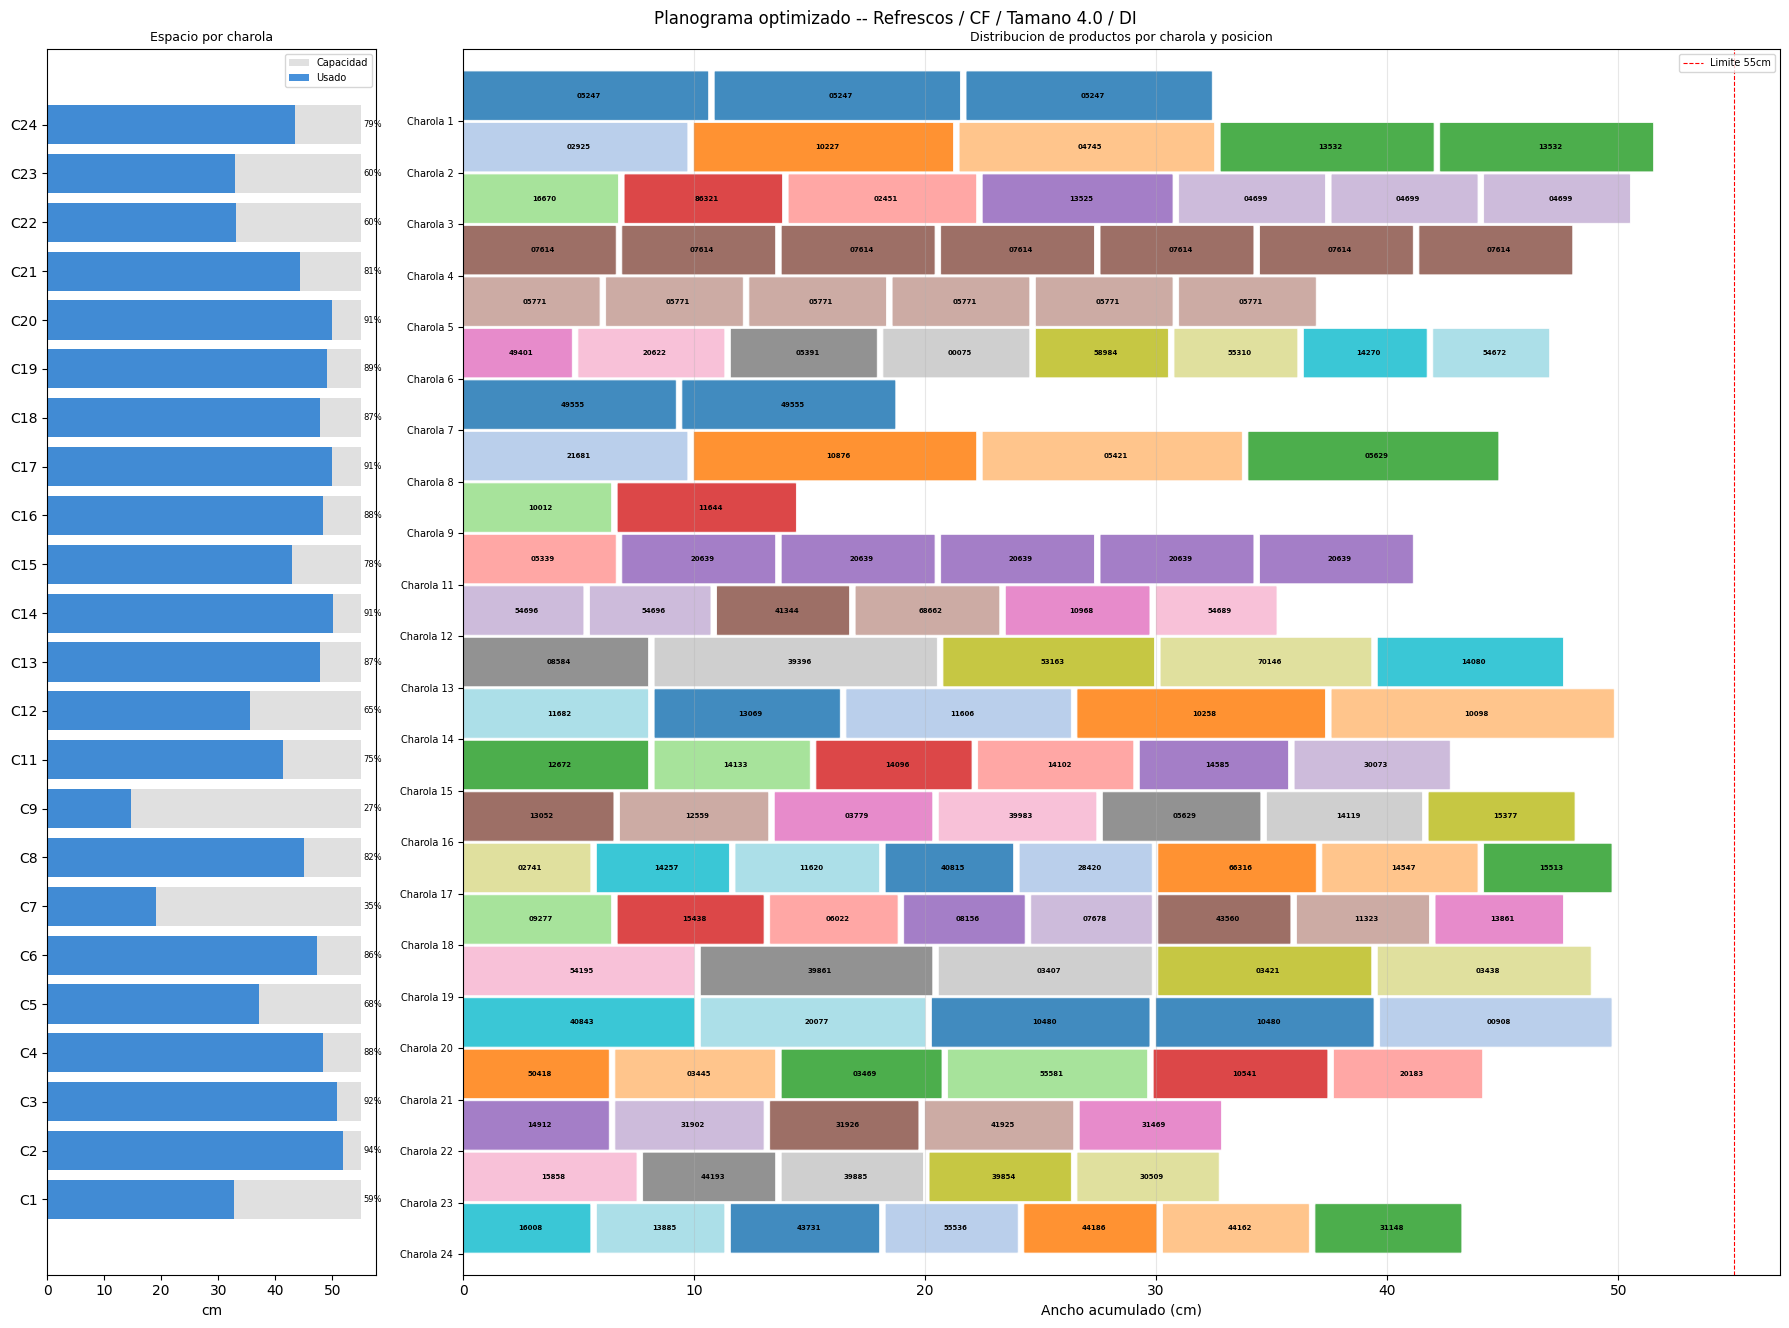

Imagen guardada: out/planograma_resultado.png


In [124]:
# -- Celda 17: Visualización del planograma
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from collections import defaultdict as _dv

charolas_con_datos = sorted(df_resultado['CHAROLA'].unique(), reverse=True)
A_c_max = max(shelf_widths.values())

fig, (ax_bar, ax_plan) = plt.subplots(1, 2,
    figsize=(18, max(6, len(charolas_con_datos)*0.5+2)),
    gridspec_kw={'width_ratios': [1, 4]})
fig.suptitle(
    f'Planograma optimizado -- {PLANOGRUPO_SEL} / {MUEBLE} / Tamano {TAMANO} / {DIRECCION}',
    fontsize=12)

# Panel izquierdo: uso de espacio por charola
charola_y  = {c: i for i, c in enumerate(charolas_con_datos)}
etiquetas  = [f'C{c}' for c in charolas_con_datos]
capacidades = [shelf_widths.get(c, A_c_max) for c in charolas_con_datos]
usos        = [charola_ancho.get(c, 0) for c in charolas_con_datos]

ax_bar.barh(etiquetas, capacidades, color='#e0e0e0', label='Capacidad')
ax_bar.barh(etiquetas, usos,        color='#1976D2', alpha=0.8, label='Usado')
for i, (u, cap) in enumerate(zip(usos, capacidades)):
    ax_bar.text(cap + 0.5, i, f'{100*u/cap:.0f}%', va='center', fontsize=6)
ax_bar.set_xlabel('cm')
ax_bar.set_title('Espacio por charola', fontsize=9)
ax_bar.legend(fontsize=7)
ax_bar.invert_yaxis()

# Panel derecho: planograma visual
# x0 se recalcula desde 0 para cada charola (no usa row['X'] que trae
# el offset fisico del mueble y puede ser >55 cm para charolas altas)
cmap      = cm.get_cmap('tab20', 20)
color_map = {}

# Agrupar filas por charola y ordenar por posicion (UBICACION_BANDEJA)
charola_rows = _dv(list)
for _, row in df_resultado.iterrows():
    charola_rows[int(row['CHAROLA'])].append(row)

for c, rows_c in charola_rows.items():
    if c not in charola_y:
        continue
    x_cur = 0.0
    y0    = charola_y[c]
    for row in sorted(rows_c, key=lambda r: int(r['UBICACION_BANDEJA'])):
        upc = int(row['ITEM'])
        w   = float(row['ANCHO'])
        if upc not in color_map:
            color_map[upc] = cmap(len(color_map) % 20)
        rect = mpatches.FancyBboxPatch(
            (x_cur, y0 + 0.05), max(w - 0.3, 0.1), 0.9,
            boxstyle='round,pad=0.03',
            facecolor=color_map[upc], edgecolor='white', linewidth=0.7, alpha=0.85
        )
        ax_plan.add_patch(rect)
        if w >= 4:
            ax_plan.text(x_cur + w/2, y0 + 0.5, str(upc)[-5:],
                         ha='center', va='center', fontsize=5, fontweight='bold',
                         clip_on=True)
        x_cur += w

ax_plan.set_xlim(0, A_c_max + 2)
ax_plan.set_ylim(-0.4, len(charolas_con_datos) + 0.4)
ax_plan.set_yticks(list(charola_y.values()))
ax_plan.set_yticklabels([f'Charola {c}' for c in charolas_con_datos], fontsize=7)
ax_plan.set_xlabel('Ancho acumulado (cm)')
ax_plan.set_title('Distribucion de productos por charola y posicion', fontsize=9)
ax_plan.axvline(A_c_max, color='red', linestyle='--', linewidth=0.8,
                label=f'Limite {A_c_max:.0f}cm')
ax_plan.legend(fontsize=7)
ax_plan.grid(axis='x', alpha=0.3)

plt.tight_layout()
import os; os.makedirs('out', exist_ok=True)
plt.savefig('out/planograma_resultado.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imagen guardada: out/planograma_resultado.png')


In [125]:
# -- Celda 18: Resumen final de métricas
obj_max_posible = sum(
    max((prob_lookup.get((p, c, b), 0.0)
         for c in allowed_pc[p]
         for b in range(1, b_max(c)+1)), default=0.0)
    for p in products
)

sep = '=' * 52
print(sep)
print('  PLANOGRAMA OXXO -- Resumen final')
print(sep)
print(f'  Estado solver    : {LpStatus[lp.status]}')
print(f'  Objetivo (z)     : {value(lp.objective):.4f}')
print(f'  z normalizado    : {value(lp.objective)/max(obj_max_posible,1e-9):.2%} del máximo posible')
print(f'  Tiempo solver    : {t_solver:.2f}s')
print(f'  Productos        : {len(count_per_p)} / {len(products)} colocados')
print(f'  Celdas usadas    : {len(assignments)} / {total_cells}')
print(f'  R2 (>= N_p fren) : {"SI" if r2_ok else "NO"}')
print(f'  R3 cumplida      : {"SI" if r3_ok else "NO"}')
print(f'  R4 cumplida      : {"SI" if r4_ok else "NO"}')
print(f'  R_fill (>={FILL_MIN:.0%})  : {"SI" if r_fill_ok else "NO"}')
print(f'  R5 cumplida      : {"SI" if r5_ok else "NO"}')
print(sep)


  PLANOGRAMA OXXO -- Resumen final
  Estado solver    : Optimal
  Objetivo (z)     : 95.8333
  z normalizado    : 95.04% del máximo posible
  Tiempo solver    : 0.11s
  Productos        : 105 / 105 colocados
  Celdas usadas    : 128 / 240
  R2 (>= N_p fren) : SI
  R3 cumplida      : SI
  R4 cumplida      : SI
  R_fill (>=70%)  : NO
  R5 cumplida      : SI


Solve base (sin R_fill): Optimal  obj=99.1667  (0.1s)
⚠  Re-ejecutar celdas 10-12 para restaurar la solución con R_fill.

  C   antes   añadido   después  (umbral 50%)
──────────────────────────────────────────
C 7  34.5%  + 19.0cm    69.1%
C 9  42.2%  + 29.9cm    96.5%

  COMPARATIVA  Con R_fill  vs  Sin R_fill + Greedy
                              Con R_fill     Sin R+G
  --------------------------------------------------
  Estado solver                  Optimal     Optimal
  Objetivo (z)                   95.8333     99.1667
  Tiempo solver                    0.11s       0.11s
  Productos (105)                 105/105      105/105
  Celdas X usadas                    128         141
  --------------------------------------------------
  R2 (>= N_p frentes)                 SI          SI
  R3 (sin solapamiento)               SI          SI
  R4 (ancho <= A_c-1)                 SI          SI
  R_fill (>= 70%)                     NO  N/A (greedy)
  R5 (contigüidad)                   

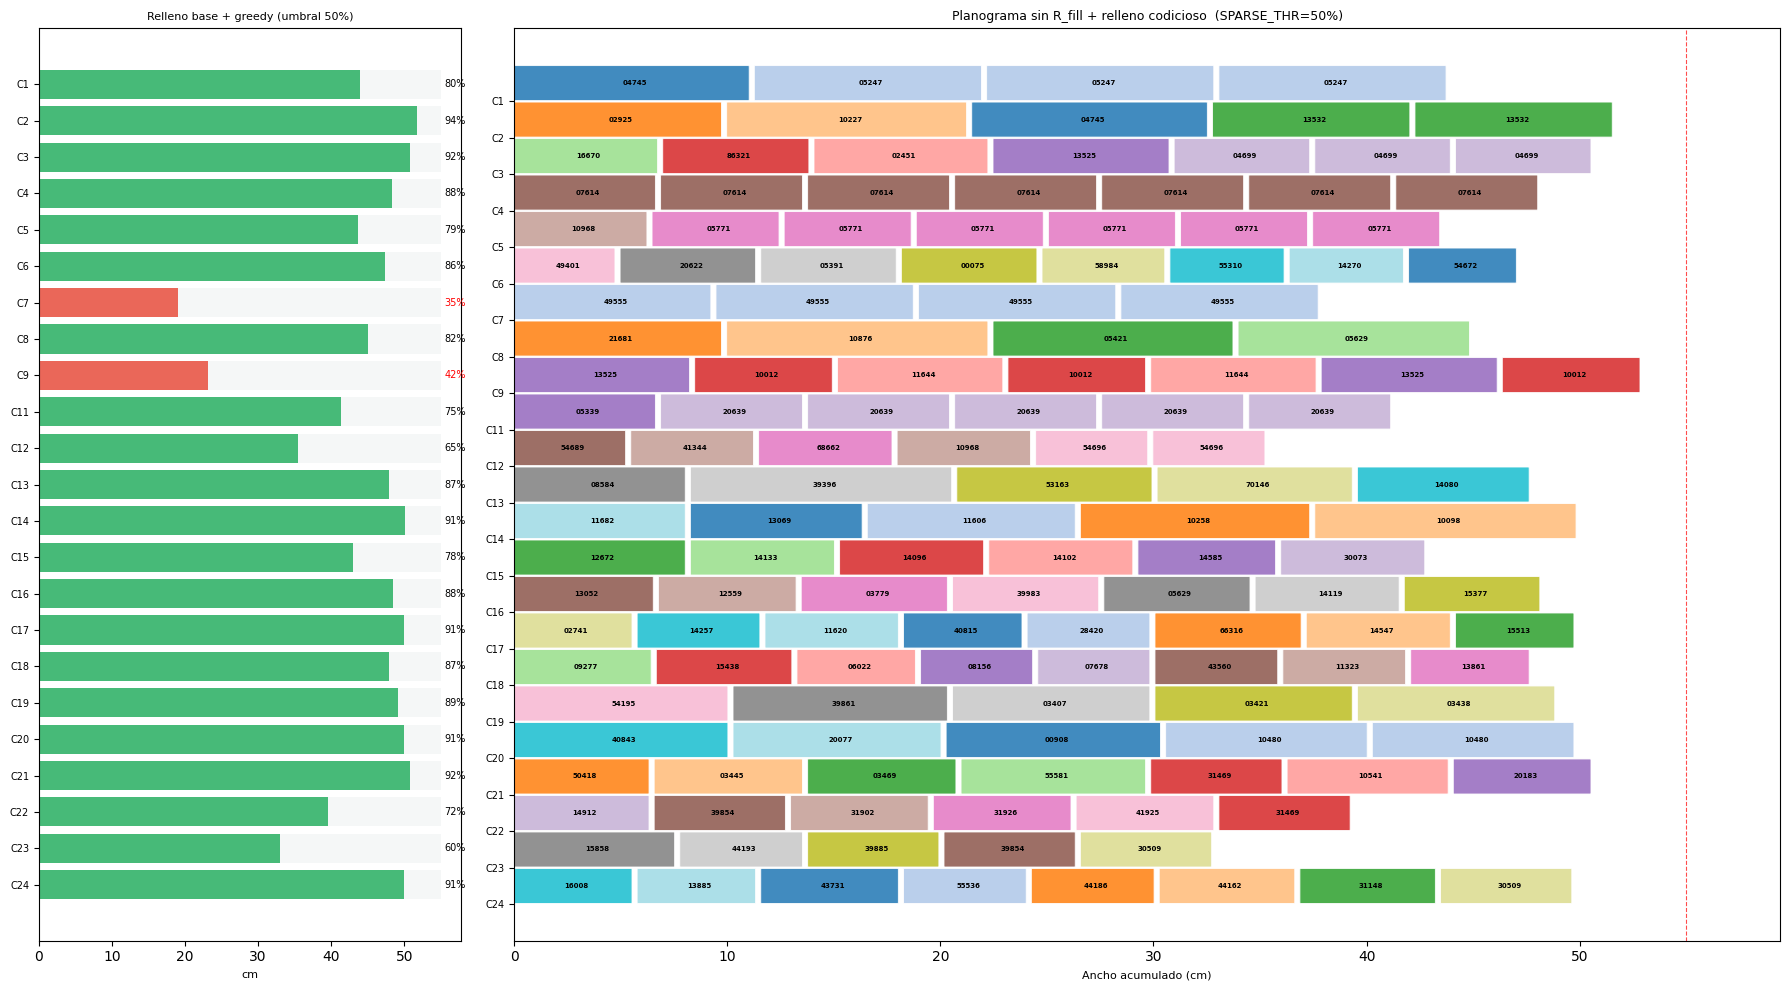

In [126]:
# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═
# CELDA: Solve base (sin R_fill) → relleno codicioso + métricas comparativas
# Prerequisito: celdas 10-18 ejecutadas (X, Y, charola_y, assignments disponibles).
# AVISO: resolver lp_base sobreescribe varValue de X, Y.
#        Re-ejecutar celdas 10-12 para restaurar la solución con R_fill.
# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═# ═
from collections import defaultdict as _dd
from pulp import LpProblem, LpMaximize, LpStatus, lpSum, value as lp_val, PULP_CBC_CMD
import pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches, time as _t

SPARSE_THR = 0.50   # charola < 50 % → candidata a relleno codicioso
FILL_SLACK = 1.0    # cm de margen al borde (igual que R4)

# ── 0. CAPTURAR MÉTRICAS DEL LP CON R_fill (antes de sobreescribir X, Y) ────────
try:
    _obj_r   = lp_val(lp.objective)
    _t_r     = t_solver
    _cells_r = len(assignments)
    _prods_r = len(set(p for p,c,b in assignments))
    _ca_r    = {c: charola_ancho.get(c, 0.0) for c in shelf_widths}
    _ver_r   = {'r2': r2_ok, 'r3': r3_ok, 'r4': r4_ok, 'rf': r_fill_ok, 'r5': r5_ok}
    _has_r   = True
except Exception as _e:
    print(f'Aviso: no se pudieron capturar métricas R_fill ({_e})')
    _has_r = False; _obj_r = None; _ca_r = {}; _ver_r = {}
    _t_r = 0; _cells_r = 0; _prods_r = 0

# ── A. CONSTRUIR LP SIN R_fill ──────────────────────────────────────────
lp_base = LpProblem('planogram_base', LpMaximize)
lp_base += lpSum(prob_lookup.get((p,c,b), 0.0) * X[(p,c,b)] for (p,c,b) in X_keys)

for p in products:
    lp_base += lpSum(X[(p,c,b)] for (c,b) in p_to_xcells[p]) >= N_p_dict[p], f'R2_{p}'

for (c,b), prods_cb in cb_to_prods.items():
    if len(prods_cb) > 1:
        lp_base += lpSum(X[(p,c,b)] for p in prods_cb) <= 1, f'R3_{c}_{b}'

for c, A_c in shelf_widths.items():
    terms = [N_p_dict[p] * ANCHO_dict[p] * lpSum(Y[(p,c,b)] for b in bs)
             for p in products
             for bs in [pc_to_ystarts.get((p,c), [])]
             if bs]
    if terms:
        lp_base += lpSum(terms) <= A_c - FILL_SLACK, f'R4_{c}'

for (p,c,b) in X_keys:
    n = N_p_dict[p]; lo = max(1, b - n + 1)
    yt = [Y[(p,c,bp)] for bp in range(lo, b+1) if (p,c,bp) in Y_set]
    if yt:
        lp_base += X[(p,c,b)] == lpSum(yt), f'R5_{p}_{c}_{b}'
    else:
        lp_base += X[(p,c,b)] == 0, f'R5z_{p}_{c}_{b}'

for p in products:
    lp_base += lpSum(Y[(p,c,b)] for (c,b) in p_to_ystarts[p]) >= 1, f'R5min_{p}'

for p in products:
    for c in allowed_pc[p]:
        bs = pc_to_ystarts.get((p,c), [])
        if bs:
            lp_base += lpSum(Y[(p,c,b)] for b in bs) <= 1, f'R5pc_{p}_{c}'

_t0 = _t.time()
lp_base.solve(PULP_CBC_CMD(msg=0, timeLimit=SOLVER_TIME_LIMIT, gapRel=SOLVER_GAP))
_t_base = _t.time() - _t0
print(f'Solve base (sin R_fill): {LpStatus[lp_base.status]}  '
      f'obj={lp_val(lp_base.objective):.4f}  ({_t_base:.1f}s)')
print('⚠  Re-ejecutar celdas 10-12 para restaurar la solución con R_fill.\n')

# ── B. EXTRAER SOLUCIÓN BASE ────────────────────────────────────────────
ystarts_base = {(p,c,b) for (p,c,b) in Y_keys
                if lp_val(Y[(p,c,b)]) is not None and lp_val(Y[(p,c,b)]) > 0.5}

prods_in_c = _dd(list); used_cm = _dd(float); max_b_in_c = _dd(int)
for (p,c,b) in ystarts_base:
    prods_in_c[c].append(p)
    used_cm[c]    += N_p_dict[p] * ANCHO_dict[p]
    max_b_in_c[c]  = max(max_b_in_c[c], b + N_p_dict[p] - 1)

base_rows = []
for (p,c,b0) in sorted(ystarts_base, key=lambda t: (t[1], t[2])):
    for slot in range(b0, b0 + N_p_dict[p]):
        base_rows.append({'ITEM': p, 'CHAROLA': c,
                          'UBICACION_BANDEJA': slot, 'ANCHO': ANCHO_dict[p]})

# Verificación restricciones modelo base
_base_cnt = _dd(int)
for (p,c,b) in ystarts_base:
    _base_cnt[p] += N_p_dict[p]
r2_base = all(_base_cnt.get(p,0) >= N_p_dict[p] for p in products)

_cb_occ = _dd(int)
for (p,c,b) in ystarts_base:
    for s in range(b, b + N_p_dict[p]):
        _cb_occ[(c,s)] += 1
r3_base = all(v <= 1 for v in _cb_occ.values())

r4_base = all(used_cm.get(c,0) <= A_c - 0.999 for c, A_c in shelf_widths.items())

r5_base = True
_pc_sl = _dd(list)
for (p,c,b) in ystarts_base:
    for s in range(b, b + N_p_dict[p]):
        _pc_sl[(p,c)].append(s)
for (p,c), ss in _pc_sl.items():
    ss = sorted(ss)
    if any(ss[i+1]-ss[i] != 1 for i in range(len(ss)-1)):
        r5_base = False; break

_n_base   = len(set(p for (p,c,b) in ystarts_base))
_cells_base = len(base_rows)

# ── C. RELLENO CODICIOSO ───────────────────────────────────────────────
def _prio_base(p, c):
    return sum(prob_lookup.get((p,c,b), 0.0) for b in pc_to_ystarts.get((p,c), []))

greedy_extras  = []   # lista de (p, c, slot)
_added_per_c   = {}   # c → cm añadidos por greedy

print(f'{"C":>3}  {"antes":>6}  {"añadido":>8}  {"después":>8}  (umbral {SPARSE_THR:.0%})')
print('─' * 42)

for c, A_c in sorted(shelf_widths.items()):
    fb = used_cm[c] / A_c if A_c > 0 else 1.0
    if fb >= SPARSE_THR:
        continue
    remaining  = A_c - used_cm[c] - FILL_SLACK
    candidates = sorted(set(prods_in_c[c]), key=lambda p: _prio_base(p,c), reverse=True)
    if not candidates: continue
    vb = max_b_in_c[c]; idx = 0; no_fit = 0; added = 0.0
    while remaining > 0 and no_fit < len(candidates):
        p  = candidates[idx % len(candidates)]
        bw = N_p_dict[p] * ANCHO_dict[p]
        if bw <= remaining:
            for slot in range(vb + 1, vb + 1 + N_p_dict[p]):
                greedy_extras.append((p, c, slot))
            vb += N_p_dict[p]; remaining -= bw; added += bw; no_fit = 0
        else:
            no_fit += 1
        idx += 1
    _added_per_c[c] = added
    print(f'C{c:>2}  {fb:>5.1%}  +{added:>5.1f}cm  '
          f'{min((used_cm[c]+added)/A_c, 1.0):>7.1%}')

if not greedy_extras:
    print('  (ninguna charola por debajo del umbral)')

# ── MÉTRICAS COMPARATIVAS ──────────────────────────────────────────────
sep62 = '=' * 62
def _ok(v): return 'SI' if v else 'NO'
_h_prods = f'Productos ({len(products)})'

print('\n' + sep62)
print('  COMPARATIVA  Con R_fill  vs  Sin R_fill + Greedy')
print(sep62)
print(f'  {"":26}  {"Con R_fill":>10}  {"Sin R+G":>10}')
print('  ' + '-' * 50)
print(f'  {"Estado solver":26}  {"Optimal" if _has_r else "?":>10}  {LpStatus[lp_base.status]:>10}')
if _has_r:
    print(f'  {"Objetivo (z)":26}  {_obj_r:>10.4f}  {lp_val(lp_base.objective):>10.4f}')
    print(f'  {"Tiempo solver":26}  {_t_r:>9.2f}s  {_t_base:>9.2f}s')
    print(f'  {_h_prods:26}  {_prods_r:>7}/{len(products)}  {_n_base:>7}/{len(products)}')
    print(f'  {"Celdas X usadas":26}  {_cells_r:>10}  {_cells_base:>10}')
print('  ' + '-' * 50)
if _has_r:
    print(f'  {"R2 (>= N_p frentes)":26}  {_ok(_ver_r["r2"]):>10}  {_ok(r2_base):>10}')
    print(f'  {"R3 (sin solapamiento)":26}  {_ok(_ver_r["r3"]):>10}  {_ok(r3_base):>10}')
    print(f'  {"R4 (ancho <= A_c-1)":26}  {_ok(_ver_r["r4"]):>10}  {_ok(r4_base):>10}')
    print(f'  {"R_fill (>= " + format(FILL_MIN, ".0%") + ")":26}  {_ok(_ver_r["rf"]):>10}  {"N/A (greedy)":>10}')
    print(f'  {"R5 (contig\u00fcidad)":26}  {_ok(_ver_r["r5"]):>10}  {_ok(r5_base):>10}')
print(sep62)

# Tabla fill por charola
print(f'\n  Fill por charola:')
print(f'  {"C":>3}  {"R_fill":>8}  {"Base":>8}  {"B+Greedy":>8}')
print('  ' + '-' * 36)
for c, A_c in sorted(shelf_widths.items()):
    fr_b = used_cm.get(c, 0.0) / A_c if A_c else 0
    fr_g = min((used_cm.get(c,0) + _added_per_c.get(c,0)) / A_c, 1.0) if A_c else 0
    col_r = f'{_ca_r.get(c,0)/A_c:.0%}' if (_has_r and A_c) else '?'
    flag  = ' *' if _added_per_c.get(c, 0) > 0 else ''
    print(f'  C{c:>2}  {col_r:>8}  {fr_b:>8.0%}  {fr_g:>8.0%}{flag}')
print('  (* greedy añadió productos en esta charola)\n')

# ── D. CONSTRUIR df_aug ─────────────────────────────────────────────────
extra_rows = [{'ITEM': p, 'CHAROLA': c, 'UBICACION_BANDEJA': slot,
               'ANCHO': ANCHO_dict[p]}
              for (p, c, slot) in greedy_extras]
df_aug = pd.DataFrame(base_rows + extra_rows)
print(f'df_aug: {len(base_rows)} filas base + {len(extra_rows)} extras greedy '
      f'= {len(df_aug)} filas, {df_aug["ITEM"].nunique()} prods únicos')

# ── E. VISUALIZACIÓN ───────────────────────────────────────────────────
_cha_aug  = _dd(float)
_seen_aug = _dd(set)
for _, row in df_aug.iterrows():
    upc = int(row['ITEM']); c_ = int(row['CHAROLA'])
    if upc not in _seen_aug[c_]:
        _cha_aug[c_] += N_p_dict.get(upc, 1) * float(row['ANCHO'])
        _seen_aug[c_].add(upc)

try:
    _cy = charola_y
except NameError:
    _cy = {c: i for i, c in enumerate(sorted(shelf_widths.keys()))}

A_max   = max(shelf_widths.values())
chars_s = sorted(_cy, key=_cy.get)

fig_g, (ax_b, ax_p) = plt.subplots(1, 2, figsize=(18, 10),
                                     gridspec_kw={'width_ratios': [1, 3]})
cmap_g   = plt.cm.get_cmap('tab20')
cmap_map = {}

for c in chars_s:
    A_c  = shelf_widths.get(c, A_max)
    used = _cha_aug.get(c, 0.0)
    pct  = used / A_c if A_c > 0 else 0
    i    = _cy[c]
    col  = '#27ae60' if pct >= SPARSE_THR else '#e74c3c'
    ax_b.barh(i, used,       color=col,      alpha=0.85)
    ax_b.barh(i, A_c - used, left=used,  color='#ecf0f1', alpha=0.5)
    ax_b.text(A_c + 0.5, i, f'{pct:.0%}', va='center', fontsize=7,
              color='red' if pct < SPARSE_THR else 'black')

ax_b.set_yticks([_cy[c] for c in chars_s])
ax_b.set_yticklabels([f'C{c}' for c in chars_s], fontsize=7)
ax_b.set_xlabel('cm', fontsize=8)
ax_b.set_title(f'Relleno base + greedy (umbral {SPARSE_THR:.0%})', fontsize=8)

charola_rows_g = _dd(list)
for _, row in df_aug.iterrows():
    charola_rows_g[int(row['CHAROLA'])].append(row)

ax_p.set_xlim(0, A_max * 1.08)
ax_p.set_ylim(-1, len(_cy) + 1)
ax_p.axvline(A_max, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

for c, rows_c in charola_rows_g.items():
    if c not in _cy:
        continue
    x_cur = 0.0; y0 = _cy[c]
    for row in sorted(rows_c, key=lambda r: int(r['UBICACION_BANDEJA'])):
        upc = int(row['ITEM']); w = float(row['ANCHO'])
        if upc not in cmap_map:
            cmap_map[upc] = cmap_g(len(cmap_map) % 20)
        ax_p.add_patch(mpatches.FancyBboxPatch(
            (x_cur, y0 + 0.05), max(w - 0.3, 0.1), 0.9,
            boxstyle='round,pad=0.03',
            facecolor=cmap_map[upc], edgecolor='white', linewidth=0.7, alpha=0.85))
        if w >= 4:
            ax_p.text(x_cur + w/2, y0 + 0.5, str(upc)[-5:],
                      ha='center', va='center', fontsize=5, fontweight='bold',
                      clip_on=True)
        x_cur += w

ax_p.set_yticks([_cy[c] for c in chars_s])
ax_p.set_yticklabels([f'C{c}' for c in chars_s], fontsize=7)
ax_p.set_xlabel('Ancho acumulado (cm)', fontsize=8)
ax_p.set_title(
    f'Planograma sin R_fill + relleno codicioso  (SPARSE_THR={SPARSE_THR:.0%})',
    fontsize=9)
plt.tight_layout()
plt.show()


In [127]:
# ── Celda 19: Función solve_for_segmento() — pipeline completo por segmento ──
# Thread-safe: cada llamada crea su propio LpProblem independiente.
# CBC corre como subprocess → ThreadPoolExecutor da paralelismo REAL.

from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict as _dd
import time as _time_mod
from pulp import (LpProblem, LpMaximize, LpVariable, LpBinary,
                  lpSum, LpStatus, value as lp_value, PULP_CBC_CMD)


def solve_for_segmento(segmento):
    """
    Ejecuta el pipeline MILP completo para un segmento específico.
    Usa las variables globales: MUEBLE, PLANOGRUPO_SEL, TAMANO, DIRECCION,
    CONJUNTO_ID, SOLVER_TIME_LIMIT, SOLVER_GAP, ACTIVE_PAIRS_ONLY,
    df_oxxo, df_xlsx, catalog.

    Retorna dict:
        segmento, df (DataFrame o None), status, t (segundos),
        n_prod (colocados), n_total (catálogo), obj (valor objetivo)
    """
    t0 = _time_mod.time()

    # ── 1. Filtrar historial para este segmento
    df_s = df_oxxo[
        (df_oxxo['MUEBLE_ID']        == MUEBLE)         &
        (df_oxxo['PLANOGRUPO']        == PLANOGRUPO_SEL) &
        (df_oxxo['TAMANO']            == TAMANO)         &
        (df_oxxo['DIRECCION_LEGO_ID'] == DIRECCION)      &
        (df_oxxo['SEGMENTO_ID']       == segmento)
    ].copy()

    if df_s.empty:
        return {'segmento': segmento, 'df': None, 'status': 'NoData',
                't': 0.0, 'n_prod': 0, 'n_total': 0, 'obj': 0.0}

    # ── 2. Probabilidades P_{p,c,b}
    cpb = df_s.groupby(['UPC_CVE', 'CHAROLA', 'UBICACION_BANDEJA']).size().rename('cnt').reset_index()
    cp_ = df_s.groupby('UPC_CVE').size().rename('tot').reset_index()
    pf  = cpb.merge(cp_, on='UPC_CVE')
    pf['prob']             = pf['cnt'] / pf['tot']
    pf['CHAROLA']          = pf['CHAROLA'].astype(int)
    pf['UBICACION_BANDEJA']= pf['UBICACION_BANDEJA'].astype(int)
    prob_lkp = {(int(r.UPC_CVE), int(r.CHAROLA), int(r.UBICACION_BANDEJA)): float(r.prob)
                for r in pf.itertuples(index=False)}

    # ── 3. Parámetros de producto (N_p, ANCHO)
    def _mode_int(s):
        m = s.mode()
        return int(m.iloc[0]) if not m.empty else int(s.max())

    pp       = df_s.groupby('UPC_CVE').agg(ANCHO=('ANCHO', 'median'),
                                            N_p  =('NUM_FRENTES', _mode_int))
    products = pp.index.tolist()
    Np       = pp['N_p'].to_dict()
    Aw       = pp['ANCHO'].to_dict()

    # ── 4. Dimensiones del mueble (df_xlsx es sólo lectura → thread-safe)
    dx = df_xlsx[(df_xlsx['MUEBLE_ID'] == MUEBLE) & (df_xlsx['PLANOGRUPO'] == PLANOGRUPO_SEL)].copy()
    avail = dx['TAMANO_POST'].dropna().unique()
    t_use = TAMANO if TAMANO in avail else min(avail, key=lambda t: abs(t - TAMANO))
    dx = dx[dx['TAMANO_POST'] == t_use]
    if DIRECCION in dx['DIRECCION_LEGO_ID'].values:
        dx = dx[dx['DIRECCION_LEGO_ID'] == DIRECCION]

    sg    = dx.groupby('CHAROLA')
    sw    = sg['Width'].first().astype(float).to_dict()           # charola → A_c
    soff  = sg[['X', 'Y', 'Height']].first().to_dict('index')    # charola → offsets
    charolas = sorted(sw.keys())

    bh     = df_s.groupby('CHAROLA')['UBICACION_BANDEJA'].max().astype(int).to_dict()
    min_a  = float(df_s['ANCHO'].min())
    bc     = {c: max(int((w - 1.0) / min_a), 1) for c, w in sw.items()}
    def bmax(c): return max(bh.get(c, 1), bc.get(c, 1))

    # ── 5. Generar claves de variables X e Y
    obs_c = (pf.groupby('UPC_CVE')['CHAROLA']
               .apply(lambda s: sorted(s.unique().astype(int).tolist()))
               .to_dict()) if ACTIVE_PAIRS_ONLY else {}

    apc    = {p: ([c for c in obs_c.get(p, []) if c in set(charolas)] or charolas)
              for p in products}

    X_keys, Y_keys = [], []
    for p in products:
        n = Np[p]
        for c in apc[p]:
            bm = bmax(c)
            for b in range(1, bm + 1):
                X_keys.append((p, c, b))
            for b in range(1, max(1, bm - n + 2)):  # posiciones de inicio válidas
                Y_keys.append((p, c, b))

    Y_set    = set(Y_keys)
    p_xcells = _dd(list); cb_prods = _dd(list)
    pc_yst   = _dd(list); p_yst    = _dd(list)
    for (p, c, b) in X_keys:
        p_xcells[p].append((c, b)); cb_prods[(c, b)].append(p)
    for (p, c, b) in Y_keys:
        pc_yst[(p, c)].append(b);   p_yst[p].append((c, b))

    # ── 6. Construir MILP (nombre único por segmento para evitar colisiones)
    pfx = segmento.replace(' ', '_')
    lp  = LpProblem(f'OXXO_{pfx}', LpMaximize)
    Xv  = {k: LpVariable(f'X{pfx}_{k[0]}_{k[1]}_{k[2]}', cat=LpBinary) for k in X_keys}
    Yv  = {k: LpVariable(f'Y{pfx}_{k[0]}_{k[1]}_{k[2]}', cat=LpBinary) for k in Y_keys}

    # Objetivo
    lp += lpSum(prob_lkp.get((p, c, b), 0.0) * Xv[(p, c, b)] for (p, c, b) in X_keys)
    # R2: todos los productos se colocan
    for p in products:
        lp += lpSum(Xv[(p, c, b)] for (c, b) in p_xcells[p]) >= Np[p]
    # R3: sin solapamiento
    for (c, b), pl in cb_prods.items():
        if len(pl) > 1:
            lp += lpSum(Xv[(p, c, b)] for p in pl) <= 1
    # R4: ancho por charola
    for c, Ac in sw.items():
        terms = [Np[p] * Aw[p] * lpSum(Yv[(p, c, b)] for b in pc_yst[(p, c)])
                 for p in products if pc_yst[(p, c)]]
        if terms:
            lp += lpSum(terms) <= Ac - 1.0
    # R_fill: cada charola al menos FILL_MIN de su capacidad
    for c, Ac in sw.items():
        fill_terms = [Np[p] * Aw[p] * lpSum(Yv[(p, c, b)] for b in pc_yst[(p, c)])
                      for p in products if pc_yst[(p, c)]]
        if fill_terms:
            lp += lpSum(fill_terms) >= FILL_MIN * Ac
    # R5: contigüidad (link X↔Y) + inicio único
    for (p, c, b) in X_keys:
        n  = Np[p]; lo = max(1, b - n + 1)
        yt = [Yv[(p, c, bp)] for bp in range(lo, b + 1) if (p, c, bp) in Y_set]
        lp += Xv[(p, c, b)] == (lpSum(yt) if yt else 0)
    for p in products:
        lp += lpSum(Yv[(p, c, b)] for (c, b) in p_yst[p]) >= 1
    # R5c: un producto inicia a lo mas una vez por charola (multi-charola permitido)
    for p in products:
        for c in apc[p]:
            bs_pc = pc_yst[(p, c)]
            if bs_pc:
                lp += lpSum(Yv[(p, c, b)] for b in bs_pc) <= 1

    # ── 7. Resolver
    PULP_CBC_CMD(msg=0, timeLimit=SOLVER_TIME_LIMIT, gapRel=SOLVER_GAP).solve(lp)
    t_solver = _time_mod.time() - t0

    # ── 8. Extraer asignaciones
    asgn = [(int(p), int(c), int(b)) for (p, c, b) in X_keys
            if lp_value(Xv[(p, c, b)]) is not None and lp_value(Xv[(p, c, b)]) > 0.5]

    # ── 9. Post-proceso → DataFrame
    cp_map = _dd(list)
    for (u, c, b) in asgn: cp_map[c].append((b, u))

    def _ref(t):
        ts = str(int(t)) if t == int(t) else str(t)
        return f'{CONJUNTO_ID}_{segmento}_{PLANOGRUPO_SEL}-{MUEBLE}_({ts}){DIRECCION}'

    rows = []
    for c in sorted(cp_map.keys()):
        off   = soff.get(c, {'X': 0.0, 'Y': 0.0, 'Height': 1.0})
        x_cur = float(off['X']); Y_sh = float(off['Y']); Ht = float(off['Height'])
        Ac    = sw.get(c, 55.0)
        for (b, upc) in sorted(cp_map[c]):
            info = catalog.get(upc, {'ITEM_DESC': f'UPC_{upc}', 'ALTO': 25.0})
            rows.append({
                'SEGMENTO_ID': segmento,     'MUEBLE_ID': MUEBLE,
                'PLANOGRUPO':  PLANOGRUPO_SEL,'TAMANO_POST': TAMANO,
                'DIRECCION_LEGO_ID': DIRECCION,
                'ITEM': upc,  'ITEM_DESC': info.get('ITEM_DESC', f'UPC_{upc}'),
                'CHAROLA': c, 'UBICACION_BANDEJA': b,
                'NUM_FRENTES': Np[upc],      'ALTO': info.get('ALTO', 25.0),
                'ANCHO': Aw[upc],            'Width': Ac, 'Height': Ht,
                'X': round(x_cur, 2),        'Y': round(Y_sh, 2),
                'DISENO_REFERENCIA': _ref(TAMANO),
                'SEPARADOR': 0, 'SQUEEZE': 1,
            })
            x_cur += Aw[upc]

    df_out   = pd.DataFrame(rows) if rows else pd.DataFrame()
    n_placed = df_out['ITEM'].nunique() if not df_out.empty else 0

    return {
        'segmento': segmento, 'df': df_out,
        'status':   LpStatus[lp.status],
        't':        t_solver, 'n_prod': n_placed,
        'n_total':  len(products),
        'obj':      lp_value(lp.objective) or 0.0,
    }


print('solve_for_segmento() definida — lista para batch paralelo (Celda 20).')

solve_for_segmento() definida — lista para batch paralelo (Celda 20).


In [128]:
# ── Celda 20: Batch paralelo — todos los segmentos al mismo tiempo ──────────
# Descubre automáticamente los segmentos disponibles para el formato actual
# y los resuelve en paralelo con ThreadPoolExecutor.
# (CBC corre como subprocess externo → GIL no bloquea → paralelismo REAL)
#
# Prerequisito: haber ejecutado Celda 1 (cargar datos) y Celda 19 (definir función).
# Los parámetros MUEBLE / PLANOGRUPO_SEL / TAMANO / DIRECCION vienen de Celda 3.

import os

# ── Detectar segmentos disponibles para este formato
mask_fmt = (
    (df_oxxo['MUEBLE_ID']        == MUEBLE)         &
    (df_oxxo['PLANOGRUPO']        == PLANOGRUPO_SEL) &
    (df_oxxo['TAMANO']            == TAMANO)         &
    (df_oxxo['DIRECCION_LEGO_ID'] == DIRECCION)
)
segmentos_disp = sorted(df_oxxo[mask_fmt]['SEGMENTO_ID'].dropna().unique().tolist())

print(f'Formato  : {MUEBLE} / {PLANOGRUPO_SEL} / Tam={TAMANO} / Dir={DIRECCION}')
print(f'Segmentos: {segmentos_disp}  ({len(segmentos_disp)} en paralelo)')
print(f'Params   : time_limit={SOLVER_TIME_LIMIT}s, gap={SOLVER_GAP:.0%}, '
      f'active_pairs={ACTIVE_PAIRS_ONLY}')
print('-' * 55)

os.makedirs('out', exist_ok=True)
resultados_batch = {}
t_batch_ini = _time_mod.time()

# ── Lanzar todos los segmentos simultáneamente
with ThreadPoolExecutor(max_workers=len(segmentos_disp)) as executor:
    futures = {executor.submit(solve_for_segmento, seg): seg
               for seg in segmentos_disp}

    for future in as_completed(futures):
        r   = future.result()
        seg = r['segmento']
        resultados_batch[seg] = r

        # Guardar CSV individual al terminar cada segmento
        if r['df'] is not None and not r['df'].empty:
            t_str = str(int(TAMANO)) if TAMANO == int(TAMANO) else str(TAMANO)
            fname = f"out/planograma_{seg}_{MUEBLE}_{PLANOGRUPO_SEL}_{t_str}_{DIRECCION}.csv"
            r['df'].to_csv(fname, index=False, encoding='utf-8')
            csv_tag = f'→ {fname}'
        else:
            csv_tag = '→ (sin datos)'

        icon = 'OK' if r['status'] in ('Optimal', 'Feasible') else r['status']
        print(f"  [{icon:8s}] {seg:6s} | {r['n_prod']:3d}/{r['n_total']:3d} prod "
              f"| {r['t']:5.1f}s | obj={r['obj']:.4f}  {csv_tag}")

t_batch_total = _time_mod.time() - t_batch_ini
t_seq_equiv   = sum(r['t'] for r in resultados_batch.values())
speedup       = t_seq_equiv / max(t_batch_total, 0.001)

print('-' * 55)
print(f'Tiempo paralelo   : {t_batch_total:.1f}s')
print(f'Tiempo secuencial : {t_seq_equiv:.1f}s  (suma individual)')
print(f'Speedup           : {speedup:.1f}x')

# ── Concatenar todos los resultados en un CSV consolidado
dfs_ok = [r['df'] for r in resultados_batch.values()
          if r['df'] is not None and not r['df'].empty]

if dfs_ok:
    df_todos = pd.concat(dfs_ok, ignore_index=True)
    t_str = str(int(TAMANO)) if TAMANO == int(TAMANO) else str(TAMANO)
    f_all = f"out/planograma_ALL_{MUEBLE}_{PLANOGRUPO_SEL}_{t_str}_{DIRECCION}.csv"
    df_todos.to_csv(f_all, index=False, encoding='utf-8')
    print(f'\nCSV consolidado : {f_all}')
    print(f'                  {len(df_todos)} filas | '
          f'{df_todos["SEGMENTO_ID"].nunique()} segmentos | '
          f'{df_todos["ITEM"].nunique()} UPCs únicos')
    df_todos.groupby('SEGMENTO_ID')['ITEM'].nunique().rename('UPCs').to_frame()

Formato  : CF / Refrescos / Tam=4.0 / Dir=DI
Segmentos: ['BCO', 'CLA', 'HRN', 'OFC', 'PTC', 'REC', 'RET', 'SIN']  (8 en paralelo)
Params   : time_limit=28s, gap=1%, active_pairs=True
-------------------------------------------------------
  [Infeasible] CLA    | 102/102 prod |   0.5s | obj=103.2712  → out/planograma_CLA_CF_Refrescos_4_DI.csv
  [Infeasible] BCO    | 105/105 prod |   0.6s | obj=104.6921  → out/planograma_BCO_CF_Refrescos_4_DI.csv
  [Infeasible] PTC    | 101/102 prod |   0.6s | obj=107.9615  → out/planograma_PTC_CF_Refrescos_4_DI.csv
  [Infeasible] RET    |  93/ 99 prod |   0.6s | obj=91.0833  → out/planograma_RET_CF_Refrescos_4_DI.csv
  [Infeasible] SIN    | 129/130 prod |   0.6s | obj=122.5000  → out/planograma_SIN_CF_Refrescos_4_DI.csv
  [Infeasible] OFC    | 104/104 prod |   0.6s | obj=102.9385  → out/planograma_OFC_CF_Refrescos_4_DI.csv
  [Infeasible] HRN    | 104/106 prod |   0.6s | obj=110.5000  → out/planograma_HRN_CF_Refrescos_4_DI.csv
  [OK      ] REC    | 119/1

Segmento: BCO  |  Alpha interpolación: 0.15
▶ Sin augmentación...
  Optimal  105/105 prod  0.2s  obj=95.8333
▶ Con augmentación...
  Optimal  105/105 prod  2.4s  obj=96.5833


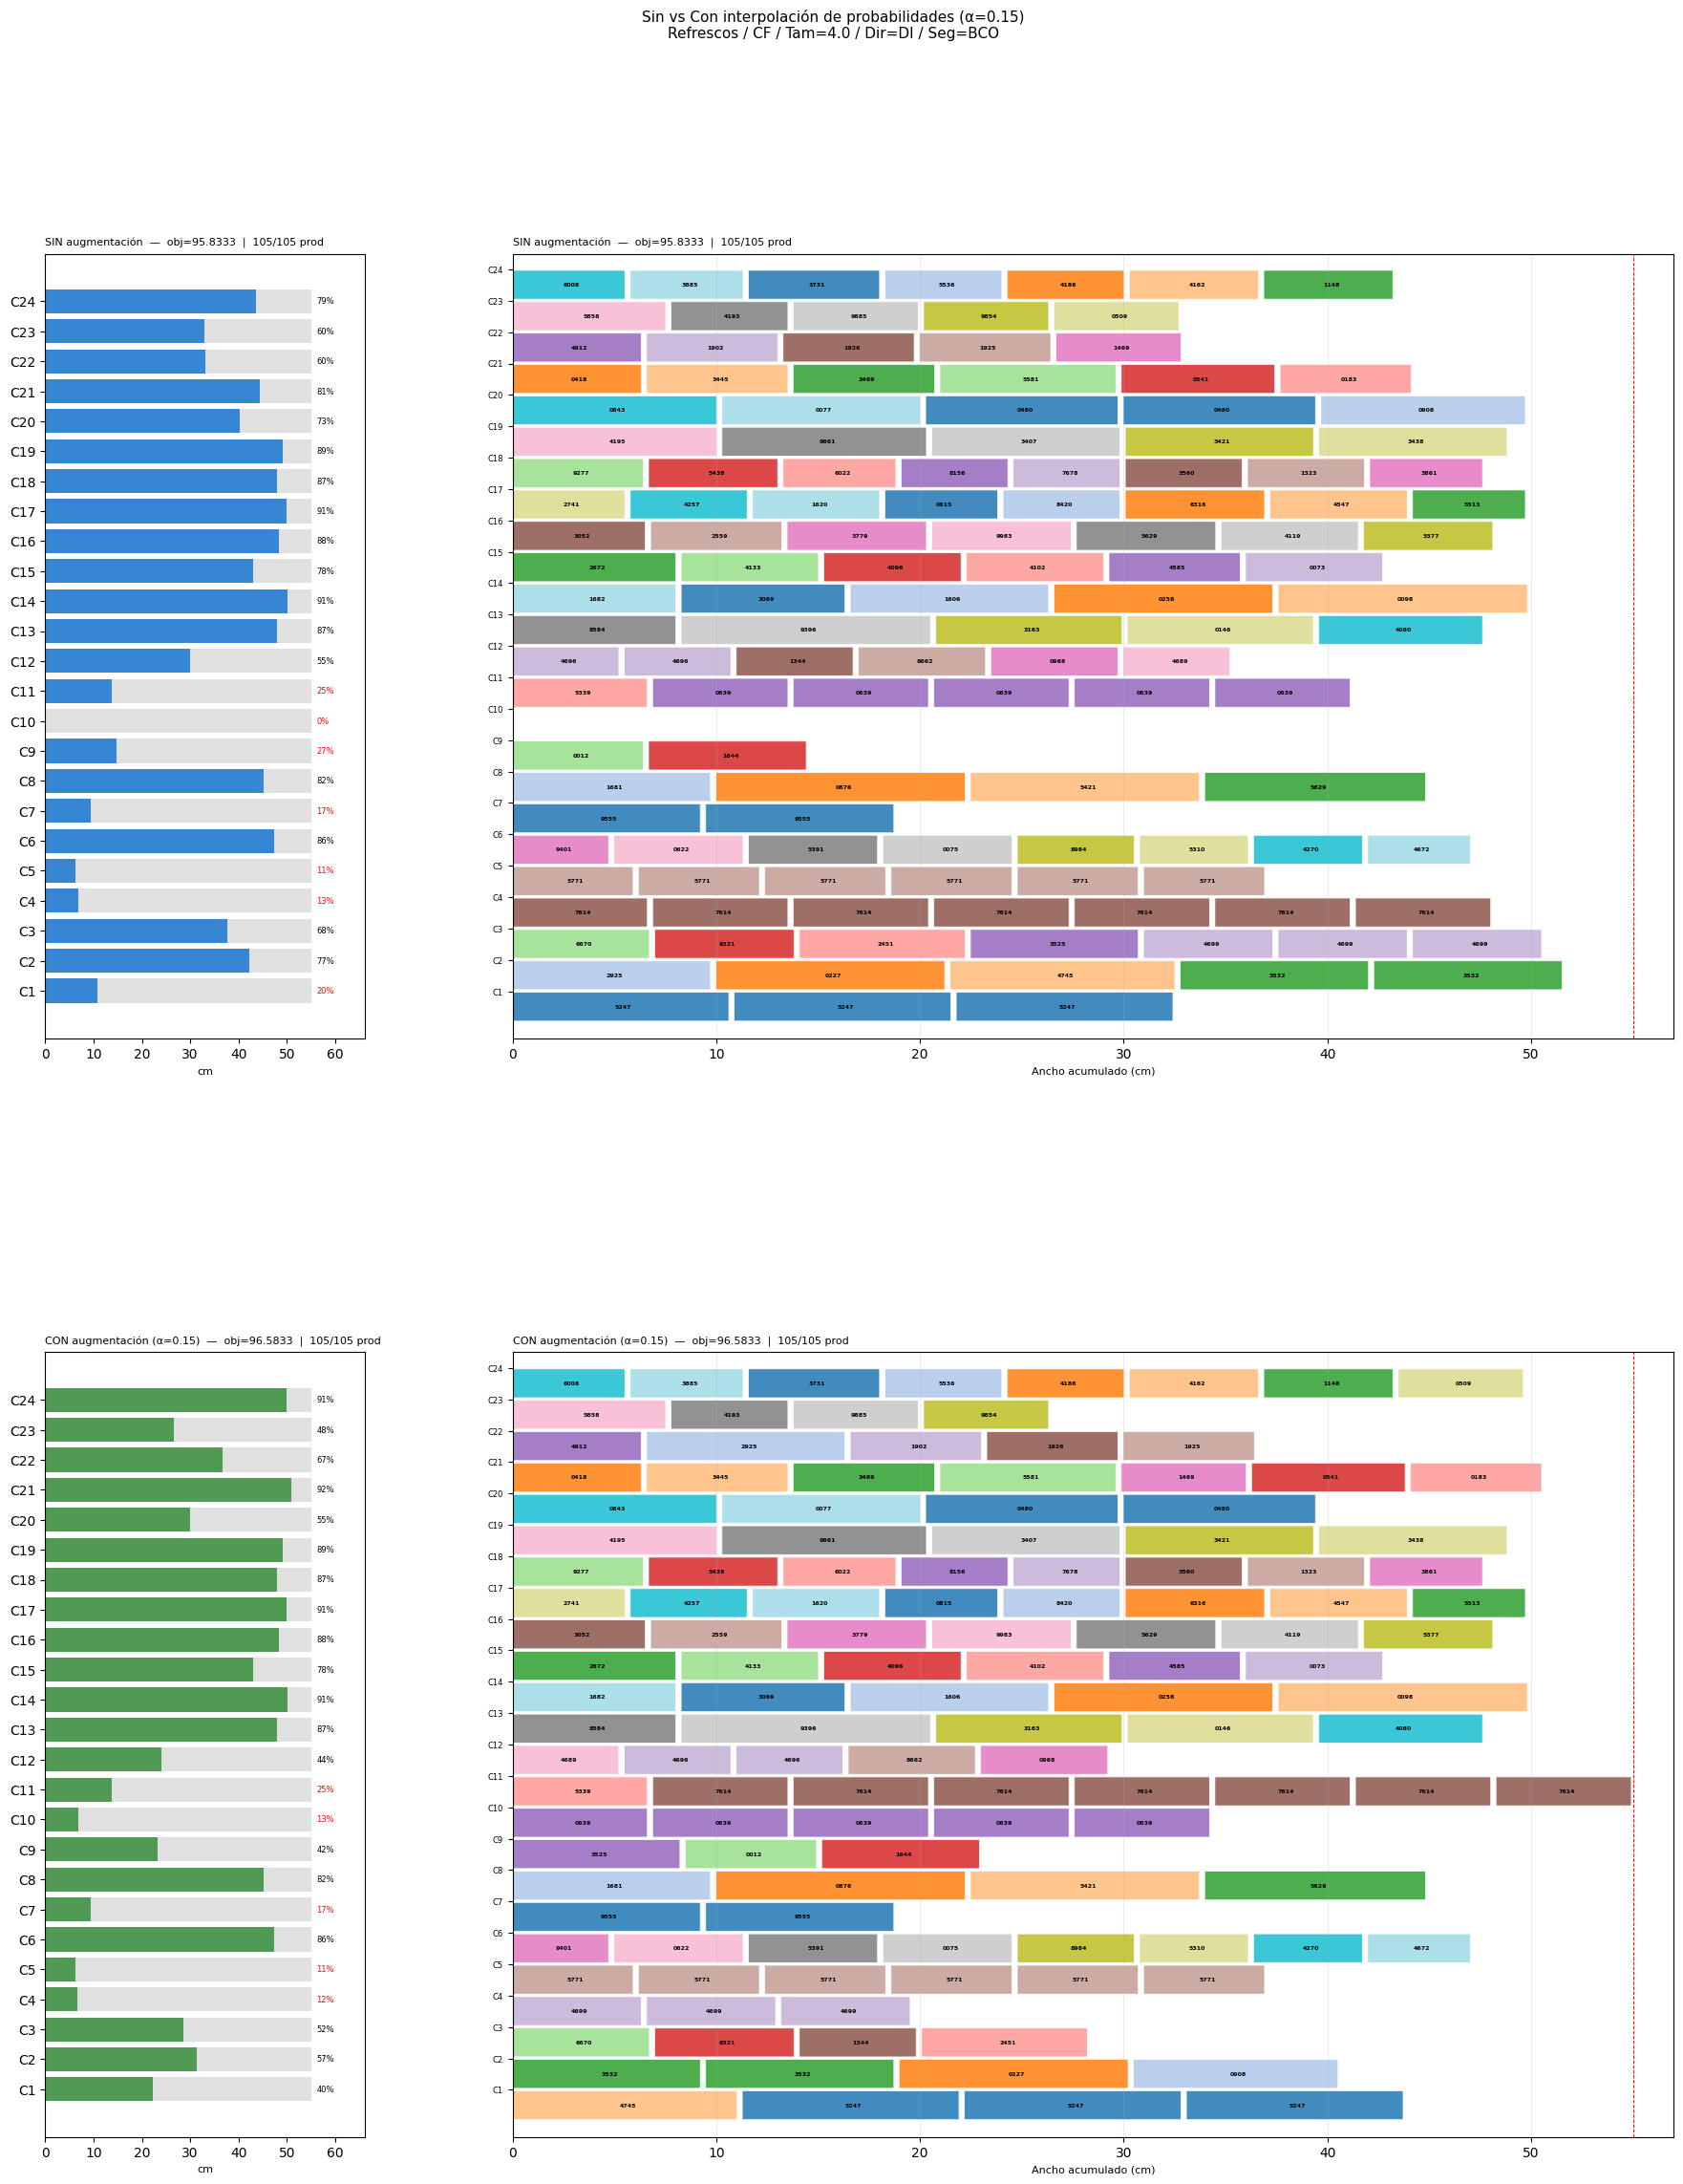

Guardado: out/comparativa_interpolacion.png

── Fill rate por charola ────────────────────────────────────────
 Charola   Cap (cm)    Sin aug    Con aug     Δ (cm)
──────────────────────────────────────────────────────
       1         55        20%        40%  +   11.3
       2         55        77%        57%    -11.0
       3         55        68%        52%     -9.1
       4         55        13%        12%     -0.3
       5         55        11%        11%  +    0.0
       6         55        86%        86%  +    0.0
       7         55        17%        17%  +    0.0
       8         55        82%        82%  +    0.0
       9         55        27%        42%  +    8.5
      10         55         0%        13%  +    6.9
      11         55        25%        25%  +    0.0
      12         55        55%        44%     -6.0
      13         55        87%        87%  +    0.0
      14         55        91%        91%  +    0.0
      15         55        78%        78%  +    0.0
     

In [129]:

# ── Celda 21: Comparativa — Sin vs Con interpolación de probabilidades ────────
# Corre el solver DOS veces para el segmento seleccionado y muestra
# un comparativo visual lado a lado (fill rate + planograma).
#
# Prerequisito: Celdas 1–7 ejecutadas (df_oxxo, df_xlsx, catalog disponibles).
# No modifica ninguna variable global.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm_plt
from collections import defaultdict as _dd2
import time as _t2
from pulp import (LpProblem, LpMaximize, LpVariable, LpBinary,
                  lpSum as _lpSum2, LpStatus as _LpSt2,
                  value as _lv2, PULP_CBC_CMD as _CBC2)

# ── Parámetros ajustables ─────────────────────────────────────────────────────
SEG_COMP   = SEGMENTO or 'BCO'   # segmento a comparar (hereda de Celda 3)
ALPHA_COMP = 0.15                 # fracción de prob. media usada como baseline


# ── Pipeline completo en una función autónoma ─────────────────────────────────
def _pipeline_cmp(alpha: float, run_lbl: str) -> dict:
    """
    Ejecuta el MILP para SEG_COMP con o sin interpolación de probabilidades.
    alpha=0 → sin augmentación (comportamiento original)
    alpha>0 → pares (p,c) faltantes reciben baseline = alpha × mean_prob / n_bandejas
    """
    t_ini = _t2.time()

    # 1. Historial del segmento
    df_s = df_oxxo[
        (df_oxxo['MUEBLE_ID']        == MUEBLE)         &
        (df_oxxo['PLANOGRUPO']        == PLANOGRUPO_SEL) &
        (df_oxxo['TAMANO']            == TAMANO)         &
        (df_oxxo['DIRECCION_LEGO_ID'] == DIRECCION)      &
        (df_oxxo['SEGMENTO_ID']       == SEG_COMP)
    ].copy()
    if df_s.empty:
        return None

    # 2. Probabilidades históricas
    cpb = df_s.groupby(['UPC_CVE','CHAROLA','UBICACION_BANDEJA']).size().rename('cnt').reset_index()
    cp_ = df_s.groupby('UPC_CVE').size().rename('tot').reset_index()
    pf  = cpb.merge(cp_, on='UPC_CVE')
    pf['prob']              = pf['cnt'] / pf['tot']
    pf['CHAROLA']           = pf['CHAROLA'].astype(int)
    pf['UBICACION_BANDEJA'] = pf['UBICACION_BANDEJA'].astype(int)

    # 3. Dimensiones del mueble (sólo lectura)
    dx = df_xlsx[(df_xlsx['MUEBLE_ID']==MUEBLE) & (df_xlsx['PLANOGRUPO']==PLANOGRUPO_SEL)].copy()
    avail = dx['TAMANO_POST'].dropna().unique()
    t_use = TAMANO if TAMANO in avail else min(avail, key=lambda t: abs(t - TAMANO))
    dx = dx[dx['TAMANO_POST'] == t_use]
    if DIRECCION in dx['DIRECCION_LEGO_ID'].values:
        dx = dx[dx['DIRECCION_LEGO_ID'] == DIRECCION]
    sg_   = dx.groupby('CHAROLA')
    sw_   = sg_['Width'].first().astype(float).to_dict()
    soff_ = sg_[['X','Y','Height']].first().to_dict('index')
    ch_   = sorted(sw_.keys())
    bh_   = df_s.groupby('CHAROLA')['UBICACION_BANDEJA'].max().astype(int).to_dict()
    min_a = float(df_s['ANCHO'].min())
    bc_   = {c: max(int((w-1.0)/min_a), 1) for c, w in sw_.items()}
    def _bm(c): return max(bh_.get(c, 1), bc_.get(c, 1))

    # 4. Augmentación de probabilidades (opcional)
    if alpha > 0:
        aug_rows = []
        for upc, grp in pf.groupby('UPC_CVE'):
            known_c  = set(grp['CHAROLA'].unique())
            miss_c   = [c for c in ch_ if c not in known_c]
            if not miss_c:
                continue
            mean_p   = float(grp['prob'].mean())
            b_vals   = sorted(grp['UBICACION_BANDEJA'].unique())
            baseline = alpha * mean_p / max(len(b_vals), 1)
            for c_m in miss_c:
                for b_ in b_vals:
                    aug_rows.append({'UPC_CVE': upc, 'CHAROLA': c_m,
                                     'UBICACION_BANDEJA': int(b_), 'prob': baseline})
        if aug_rows:
            pf = pd.concat([pf, pd.DataFrame(aug_rows)], ignore_index=True)

    plkp = {(int(r.UPC_CVE), int(r.CHAROLA), int(r.UBICACION_BANDEJA)): float(r.prob)
            for r in pf.itertuples(index=False)}

    # 5. Parámetros de producto
    def _mi(s):
        m = s.mode()
        return int(m.iloc[0]) if not m.empty else int(s.max())
    pp_  = df_s.groupby('UPC_CVE').agg(ANCHO=('ANCHO','median'), N_p=('NUM_FRENTES',_mi))
    prds = pp_.index.tolist()
    Np_  = pp_['N_p'].to_dict()
    Aw_  = pp_['ANCHO'].to_dict()

    # 6. Pares permitidos (respeta ACTIVE_PAIRS_ONLY)
    obs_ = (pf.groupby('UPC_CVE')['CHAROLA']
              .apply(lambda s: sorted(s.unique().astype(int).tolist()))
              .to_dict()) if ACTIVE_PAIRS_ONLY else {}
    apc_ = {p: ([c for c in obs_.get(p, []) if c in set(ch_)] or ch_) for p in prds}

    # 7. Variables
    Xk_, Yk_ = [], []
    for p in prds:
        n = Np_[p]
        for c in apc_[p]:
            bmc = _bm(c)
            for b in range(1, bmc+1):             Xk_.append((p, c, b))
            for b in range(1, max(1, bmc-n+2)):   Yk_.append((p, c, b))
    Ys_  = set(Yk_)
    px_  = _dd2(list); cb_  = _dd2(list)
    pcy_ = _dd2(list); py_  = _dd2(list)
    for (p,c,b) in Xk_: px_[p].append((c,b));   cb_[(c,b)].append(p)
    for (p,c,b) in Yk_: pcy_[(p,c)].append(b);  py_[p].append((c,b))

    # 8. MILP
    lp_ = LpProblem(f'CMP_{run_lbl}', LpMaximize)
    Xv_ = {k: LpVariable(f'Xc{run_lbl}_{k[0]}_{k[1]}_{k[2]}', cat=LpBinary) for k in Xk_}
    Yv_ = {k: LpVariable(f'Yc{run_lbl}_{k[0]}_{k[1]}_{k[2]}', cat=LpBinary) for k in Yk_}

    lp_ += _lpSum2(plkp.get((p,c,b), 0.0) * Xv_[(p,c,b)] for (p,c,b) in Xk_)
    for p in prds:
        lp_ += _lpSum2(Xv_[(p,c,b)] for (c,b) in px_[p]) == Np_[p]
    for (c,b), pl in cb_.items():
        if len(pl) > 1:
            lp_ += _lpSum2(Xv_[(p,c,b)] for p in pl) <= 1
    for c, Ac in sw_.items():
        t4 = [Aw_[p] * _lpSum2(Yv_[(p,c,b)] for b in pcy_[(p,c)])
              for p in prds if pcy_[(p,c)]]
        if t4:
            lp_ += _lpSum2(t4) <= Ac - 1.0
    for (p,c,b) in Xk_:
        n = Np_[p]; lo = max(1, b-n+1)
        yt = [Yv_[(p,c,bp)] for bp in range(lo, b+1) if (p,c,bp) in Ys_]
        lp_ += Xv_[(p,c,b)] == (_lpSum2(yt) if yt else 0)
    for p in prds:
        lp_ += _lpSum2(Yv_[(p,c,b)] for (c,b) in py_[p]) == 1

    # 9. Resolver
    _CBC2(msg=0, timeLimit=SOLVER_TIME_LIMIT, gapRel=SOLVER_GAP).solve(lp_)
    elapsed = _t2.time() - t_ini

    # 10. Fill por charola
    asgn_ = [(int(p),int(c),int(b)) for (p,c,b) in Xk_
             if _lv2(Xv_[(p,c,b)]) is not None and _lv2(Xv_[(p,c,b)]) > 0.5]
    seen_ = _dd2(set); fill_ = _dd2(float)
    for (u,c,b) in asgn_:
        if u not in seen_[c]:
            fill_[c] += Aw_[u]; seen_[c].add(u)

    return dict(
        asgn=asgn_, fill=fill_, sw=sw_, soff=soff_, Aw=Aw_, Np=Np_,
        chars=ch_, status=_LpSt2[lp_.status], t=elapsed,
        obj=_lv2(lp_.objective) or 0.0,
        n_prod=len({u for u,_,_ in asgn_}), n_total=len(prds),
    )


# ── Ejecutar ambas versiones ───────────────────────────────────────────────────
print(f'Segmento: {SEG_COMP}  |  Alpha interpolación: {ALPHA_COMP}')
print('▶ Sin augmentación...')
r_sin = _pipeline_cmp(0.0,        'SIN')
print(f'  {r_sin["status"]}  {r_sin["n_prod"]}/{r_sin["n_total"]} prod  '
      f'{r_sin["t"]:.1f}s  obj={r_sin["obj"]:.4f}')
print('▶ Con augmentación...')
r_con = _pipeline_cmp(ALPHA_COMP, 'CON')
print(f'  {r_con["status"]}  {r_con["n_prod"]}/{r_con["n_total"]} prod  '
      f'{r_con["t"]:.1f}s  obj={r_con["obj"]:.4f}')


# ── Visualización 2 × 2 ────────────────────────────────────────────────────────
chars_rev = sorted(r_sin['chars'], reverse=True)
etqs      = [f'C{c}' for c in chars_rev]
caps      = [r_sin['sw'].get(c, 0) for c in chars_rev]
A_c_max   = max(r_sin['sw'].values())
charola_y = {c: i for i, c in enumerate(chars_rev)}
row_h     = max(5, len(r_sin['chars']) * 0.45 + 2)
cmap_v    = cm_plt.get_cmap('tab20', 20)
col_glb   = {}   # colores compartidos entre los dos paneles

fig, axes = plt.subplots(
    2, 2, figsize=(22, row_h * 2),
    gridspec_kw={'width_ratios': [1.1, 4], 'hspace': 0.40},
)
fig.suptitle(
    f'Sin vs Con interpolación de probabilidades (α={ALPHA_COMP})\n'
    f'{PLANOGRUPO_SEL} / {MUEBLE} / Tam={TAMANO} / Dir={DIRECCION} / Seg={SEG_COMP}',
    fontsize=11,
)

for ri, (res, col_bar, titulo) in enumerate([
    (r_sin, '#1976D2',
     f'SIN augmentación  —  obj={r_sin["obj"]:.4f}  |  {r_sin["n_prod"]}/{r_sin["n_total"]} prod'),
    (r_con, '#388E3C',
     f'CON augmentación (α={ALPHA_COMP})  —  obj={r_con["obj"]:.4f}  |  {r_con["n_prod"]}/{r_con["n_total"]} prod'),
]):
    ax_b = axes[ri][0]
    ax_p = axes[ri][1]
    usos = [res['fill'].get(c, 0) for c in chars_rev]

    # Panel de barras de llenado
    ax_b.barh(etqs, caps, color='#e0e0e0')
    ax_b.barh(etqs, usos, color=col_bar, alpha=0.85)
    for i, (u, cap) in enumerate(zip(usos, caps)):
        pct = 100 * u / cap if cap > 0 else 0
        ax_b.text(cap * 1.02, i, f'{pct:.0f}%', va='center', fontsize=6,
                  color='red' if pct < 40 else 'black')
    ax_b.set_xlim(0, A_c_max * 1.2)
    ax_b.set_xlabel('cm', fontsize=8)
    ax_b.invert_yaxis()
    ax_b.set_title(titulo, fontsize=8, loc='left')

    # Panel planograma visual
    charola_prods = _dd2(list)
    for (u, c, b) in res['asgn']:
        charola_prods[c].append((b, u))

    for c in sorted(charola_prods):
        x_cur = 0.0   # siempre arrancar desde el borde izquierdo de cada charola
        y0    = charola_y.get(c, 0)
        for (b, upc) in sorted(charola_prods[c]):
            w = res['Aw'].get(upc, 8.0)
            if upc not in col_glb:
                col_glb[upc] = cmap_v(len(col_glb) % 20)
            rect = mpatches.FancyBboxPatch(
                (x_cur, y0 + 0.05), max(w - 0.3, 0.5), 0.88,
                boxstyle='round,pad=0.02',
                facecolor=col_glb[upc], edgecolor='white',
                linewidth=0.6, alpha=0.85,
            )
            ax_p.add_patch(rect)
            if w >= 5:
                ax_p.text(x_cur + w/2, y0 + 0.49, str(upc)[-4:],
                          ha='center', va='center', fontsize=4.5, fontweight='bold')
            x_cur += w

    ax_p.set_xlim(0, A_c_max + 2)
    ax_p.set_ylim(-0.5, len(r_sin['chars']) + 0.5)
    ax_p.set_yticks(list(charola_y.values()))
    ax_p.set_yticklabels([f'C{c}' for c in chars_rev], fontsize=6)
    ax_p.invert_yaxis()   # alinear orientación con el panel de barras
    ax_p.set_xlabel('Ancho acumulado (cm)', fontsize=8)
    ax_p.axvline(A_c_max, color='red', linestyle='--', linewidth=0.7)
    ax_p.grid(axis='x', alpha=0.25)
    ax_p.set_title(titulo, fontsize=8, loc='left')

import os; os.makedirs('out', exist_ok=True)
plt.savefig('out/comparativa_interpolacion.png', dpi=130, bbox_inches='tight')
plt.show()
print('Guardado: out/comparativa_interpolacion.png')

# ── Tabla de fill rate por charola ────────────────────────────────────────────
print('\n── Fill rate por charola ────────────────────────────────────────')
print(f'{"Charola":>8}  {"Cap (cm)":>9}  {"Sin aug":>9}  {"Con aug":>9}  {"Δ (cm)":>9}')
print('─' * 54)
for c in sorted(r_sin['chars']):
    cap = r_sin['sw'].get(c, 0)
    fs  = r_sin['fill'].get(c, 0)
    fc  = r_con['fill'].get(c, 0)
    d   = fc - fs
    sgn = '+' if d >= 0 else ''
    print(f'{c:>8}  {cap:>9.0f}  {100*fs/max(cap,1):>8.0f}%  '
          f'{100*fc/max(cap,1):>8.0f}%  {sgn}{d:>7.1f}')


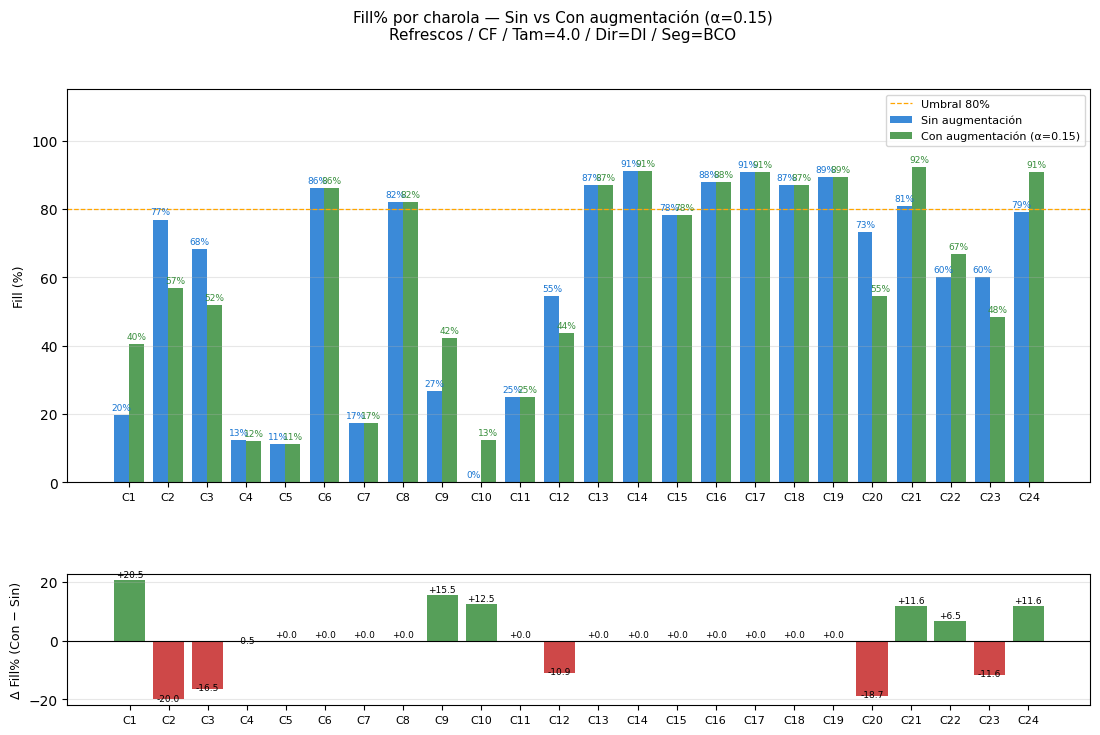

Guardado: out/comparativa_fill_pct.png

Fill global — Sin aug: 60.2%  |  Con aug: 60.2%  |  Δ = +0.0pp
Charolas que mejoran: 6  |  sin cambio: 12  |  empeoran: 6


In [130]:

# ── Celda 22: Comparativa de Fill% por charola — Sin vs Con augmentación ──────
import matplotlib.pyplot as plt
import numpy as np

chars_sorted = sorted(r_sin['chars'])
n = len(chars_sorted)

pct_sin = [100 * r_sin['fill'].get(c, 0) / max(r_sin['sw'].get(c, 1), 1) for c in chars_sorted]
pct_con = [100 * r_con['fill'].get(c, 0) / max(r_con['sw'].get(c, 1), 1) for c in chars_sorted]
delta   = [b - a for a, b in zip(pct_sin, pct_con)]

x = np.arange(n)
w = 0.38

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, n * 0.55), 8),
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35})
fig.suptitle(
    f'Fill% por charola — Sin vs Con augmentación (α={ALPHA_COMP})\n'
    f'{PLANOGRUPO_SEL} / {MUEBLE} / Tam={TAMANO} / Dir={DIRECCION} / Seg={SEG_COMP}',
    fontsize=11,
)

# ── Barras agrupadas ──────────────────────────────────────────────────────────
bars_sin = ax1.bar(x - w/2, pct_sin, w, label='Sin augmentación', color='#1976D2', alpha=0.85)
bars_con = ax1.bar(x + w/2, pct_con, w, label=f'Con augmentación (α={ALPHA_COMP})', color='#388E3C', alpha=0.85)

# Etiquetas encima de cada barra
for bar, v in zip(bars_sin, pct_sin):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.8, f'{v:.0f}%',
             ha='center', va='bottom', fontsize=6.5, color='#1976D2')
for bar, v in zip(bars_con, pct_con):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.8, f'{v:.0f}%',
             ha='center', va='bottom', fontsize=6.5, color='#388E3C')

ax1.axhline(80, color='orange', linestyle='--', linewidth=0.9, label='Umbral 80%')
ax1.set_xticks(x)
ax1.set_xticklabels([f'C{c}' for c in chars_sorted], fontsize=8)
ax1.set_ylabel('Fill (%)', fontsize=9)
ax1.set_ylim(0, 115)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# ── Panel delta ───────────────────────────────────────────────────────────────
colors_d = ['#388E3C' if d >= 0 else '#C62828' for d in delta]
ax2.bar(x, delta, color=colors_d, alpha=0.85)
for xi, d in zip(x, delta):
    ax2.text(xi, d + (0.3 if d >= 0 else -1.2), f'{d:+.1f}',
             ha='center', va='bottom', fontsize=6.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f'C{c}' for c in chars_sorted], fontsize=8)
ax2.set_ylabel('Δ Fill% (Con − Sin)', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.savefig('out/comparativa_fill_pct.png', dpi=130, bbox_inches='tight')
plt.show()
print('Guardado: out/comparativa_fill_pct.png')

# ── Resumen global ────────────────────────────────────────────────────────────
total_cap = sum(r_sin['sw'].get(c, 0) for c in chars_sorted)
fill_sin_global = 100 * sum(r_sin['fill'].get(c, 0) for c in chars_sorted) / max(total_cap, 1)
fill_con_global = 100 * sum(r_con['fill'].get(c, 0) for c in chars_sorted) / max(total_cap, 1)
print(f'\nFill global — Sin aug: {fill_sin_global:.1f}%  |  Con aug: {fill_con_global:.1f}%  '
      f'|  Δ = {fill_con_global - fill_sin_global:+.1f}pp')
n_mejor = sum(1 for d in delta if d > 0)
n_igual  = sum(1 for d in delta if d == 0)
n_peor   = sum(1 for d in delta if d < 0)
print(f'Charolas que mejoran: {n_mejor}  |  sin cambio: {n_igual}  |  empeoran: {n_peor}')


In [131]:
# ── Celda N1: solve_greedy_v2() — función batch con V2 constraints + greedy ──
# Autocontenida: crea sus propias LpVariables, no usa globales X/Y.
# Usa V2 constraints: ACTIVE_PAIRS_ONLY=True, R2==, R5_min==, sin R_fill, sin R5_pc.
# Retorna dict con métricas + df_aug (base LP + extras greedy).
# Prerequisito: ejecutar Celda 1 (datos), Celda 3 (parámetros globales).

import time as _tm
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pulp import (LpProblem, LpVariable, LpMaximize, LpStatus,
                   lpSum, value as _lp_val, PULP_CBC_CMD)

SPARSE_THR_BATCH = 0.50   # charola < 50% → candidata a greedy
FILL_SLACK_BATCH = 1.0    # cm de margen al borde (igual que R4)

def solve_greedy_v2(segmento, tamano=None):
    """
    Resuelve el planograma para (segmento, tamano) usando restricciones V2
    (sin R_fill, sin R5_pc, R2==, R5_min==) + relleno codicioso post-solve.

    Globals necesarios: MUEBLE, PLANOGRUPO_SEL, DIRECCION, CONJUNTO_ID,
                        SOLVER_TIME_LIMIT, SOLVER_GAP, df_oxxo, df_xlsx, catalog.
    """
    _tam = tamano if tamano is not None else TAMANO
    _empty = {
        'segmento': segmento, 'tamano': _tam, 'status': 'NoData',
        't_solver': 0.0, 'obj': 0.0, 'n_prod': 0, 'n_total': 0,
        'fill_before': {}, 'fill_after': {},
        'fill_avg_before': 0.0, 'fill_avg_after': 0.0,
        'n_charolas': 0, 'n_greedy_added': 0,
        'obj_max': 0.0, 'obj_norm': 0.0,
        'shelf_widths': {}, 'df_aug': pd.DataFrame(),
    }

    # 1. Filtrar historial
    df_s = df_oxxo[
        (df_oxxo['MUEBLE_ID']        == MUEBLE)         &
        (df_oxxo['PLANOGRUPO']        == PLANOGRUPO_SEL) &
        (df_oxxo['TAMANO']            == _tam)           &
        (df_oxxo['DIRECCION_LEGO_ID'] == DIRECCION)      &
        (df_oxxo['SEGMENTO_ID']       == segmento)
    ].copy()
    if df_s.empty:
        return _empty

    # 2. Probabilidades P_{p,c,b}
    cpb = (df_s.groupby(['UPC_CVE','CHAROLA','UBICACION_BANDEJA'])
               .size().rename('cnt').reset_index())
    cp_ = df_s.groupby('UPC_CVE').size().rename('tot').reset_index()
    pf  = cpb.merge(cp_, on='UPC_CVE')
    pf['prob']             = pf['cnt'] / pf['tot']
    pf['CHAROLA']          = pf['CHAROLA'].astype(int)
    pf['UBICACION_BANDEJA']= pf['UBICACION_BANDEJA'].astype(int)
    prob_lkp = {
        (int(r.UPC_CVE), int(r.CHAROLA), int(r.UBICACION_BANDEJA)): float(r.prob)
        for r in pf.itertuples(index=False)
    }

    # 3. Parámetros de producto (N_p, ANCHO)
    def _mode_int(s):
        m = s.mode(); return int(m.iloc[0]) if not m.empty else int(s.max())
    pp    = df_s.groupby('UPC_CVE').agg(ANCHO=('ANCHO','median'),
                                         N_p  =('NUM_FRENTES', _mode_int))
    prods = pp.index.tolist()
    Np    = pp['N_p'].to_dict()
    Aw    = pp['ANCHO'].to_dict()
    if not prods:
        return _empty

    # 4. Dimensiones del mueble
    dx    = df_xlsx[(df_xlsx['MUEBLE_ID']==MUEBLE) &
                    (df_xlsx['PLANOGRUPO']==PLANOGRUPO_SEL)].copy()
    avail = dx['TAMANO_POST'].dropna().unique()
    t_use = _tam if _tam in avail else min(avail, key=lambda x: abs(x - _tam))
    dx    = dx[dx['TAMANO_POST'] == t_use]
    if DIRECCION in dx['DIRECCION_LEGO_ID'].values:
        dx = dx[dx['DIRECCION_LEGO_ID'] == DIRECCION]
    sg      = dx.groupby('CHAROLA')
    sw      = sg['Width'].first().astype(float).to_dict()       # c → A_c
    charolas = sorted(sw.keys())
    if not charolas:
        return _empty

    bh    = df_s.groupby('CHAROLA')['UBICACION_BANDEJA'].max().astype(int).to_dict()
    min_a = max(float(df_s['ANCHO'].min()), 1.0)
    bc    = {c: max(int((w - 1.0) / min_a), 1) for c, w in sw.items()}
    def bmax(c): return max(bh.get(c, 1), bc.get(c, 1))

    # 5. Claves X e Y con ACTIVE_PAIRS_ONLY=True
    obs_c = (pf.groupby('UPC_CVE')['CHAROLA']
               .apply(lambda s: sorted(s.unique().astype(int).tolist()))
               .to_dict())
    apc   = {p: ([c for c in obs_c.get(p, []) if c in set(charolas)] or charolas)
              for p in prods}
    Xk, Yk = [], []
    for p in prods:
        n = Np[p]
        for c in apc[p]:
            bm = bmax(c)
            for b in range(1, bm + 1):
                Xk.append((p, c, b))
            for b in range(1, max(1, bm - n + 2)):
                Yk.append((p, c, b))
    Yset = set(Yk)

    px  = defaultdict(list)   # p → [(c,b)]
    cb  = defaultdict(list)   # (c,b) → [p]
    pcy = defaultdict(list)   # (p,c) → [b]   (start positions)
    py  = defaultdict(list)   # p → [(c,b)]   (all starts)
    for (p, c, b) in Xk:
        px[p].append((c, b)); cb[(c, b)].append(p)
    for (p, c, b) in Yk:
        pcy[(p, c)].append(b); py[p].append((c, b))

    if not Xk:
        return _empty

    # 6. Construir LP — V2 constraints
    pfx = f'{segmento}_{int(_tam)}'
    lp  = LpProblem(f'v2_{pfx}', LpMaximize)
    Xv  = {k: LpVariable(f'X{pfx}_{k[0]}_{k[1]}_{k[2]}', cat='Binary') for k in Xk}
    Yv  = {k: LpVariable(f'Y{pfx}_{k[0]}_{k[1]}_{k[2]}', cat='Binary') for k in Yk}

    # Objetivo
    lp += lpSum(prob_lkp.get((p,c,b), 0.0) * Xv[(p,c,b)] for (p,c,b) in Xk)
    # R2: exactamente N_p frentes por producto (==)
    for p in prods:
        lp += lpSum(Xv[(p,c,b)] for (c,b) in px[p]) == Np[p], f'R2_{p}'
    # R3: sin solapamiento
    for (c,b), pl in cb.items():
        if len(pl) > 1:
            lp += lpSum(Xv[(p,c,b)] for p in pl) <= 1, f'R3_{c}_{b}'
    # R4: ancho total ≤ A_c - slack
    for c, Ac in sw.items():
        terms = [Np[p] * Aw[p] * lpSum(Yv[(p,c,b)] for b in pcy[(p,c)])
                 for p in prods if pcy[(p,c)]]
        if terms:
            lp += lpSum(terms) <= Ac - FILL_SLACK_BATCH, f'R4_{c}'
    # R5a: link X ↔ Y
    for (p,c,b) in Xk:
        n = Np[p]; lo = max(1, b - n + 1)
        yt = [Yv[(p,c,bp)] for bp in range(lo, b+1) if (p,c,bp) in Yset]
        lp += Xv[(p,c,b)] == (lpSum(yt) if yt else 0), f'R5link_{p}_{c}_{b}'
    # R5b: exactamente un inicio por producto (==)
    for p in prods:
        lp += lpSum(Yv[(p,c,b)] for (c,b) in py[p]) == 1, f'R5min_{p}'

    # 7. Resolver
    t0    = _tm.time()
    PULP_CBC_CMD(msg=0, timeLimit=SOLVER_TIME_LIMIT, gapRel=SOLVER_GAP).solve(lp)
    t_sol = _tm.time() - t0

    status = LpStatus[lp.status]
    obj    = _lp_val(lp.objective) or 0.0

    if status not in ('Optimal', 'Feasible', 'Not Solved'):
        return {**_empty, 'segmento': segmento, 'tamano': _tam,
                'status': status, 't_solver': t_sol}

    # 8. Extraer solución base desde Y
    yst     = {(p,c,b) for (p,c,b) in Yk
               if _lp_val(Yv[(p,c,b)]) is not None and _lp_val(Yv[(p,c,b)]) > 0.5}
    used    = defaultdict(float)
    maxb    = defaultdict(int)
    p_in_c  = defaultdict(list)
    for (p,c,b) in yst:
        used[c]   += Np[p] * Aw[p]
        maxb[c]    = max(maxb[c], b + Np[p] - 1)
        p_in_c[c].append(p)

    base_rows = []
    for (p,c,b0) in sorted(yst, key=lambda t_: (t_[1], t_[2])):
        for s in range(b0, b0 + Np[p]):
            base_rows.append({'ITEM': p, 'CHAROLA': c,
                               'UBICACION_BANDEJA': s, 'ANCHO': Aw[p]})

    fill_before = {c: used.get(c, 0.0) / sw[c] if sw[c] else 0.0 for c in sw}

    # 9. Greedy fill
    def _prio(p, c):
        return sum(prob_lkp.get((p, c, b), 0.0) for b in pcy[(p, c)])

    extras   = []
    added_c  = defaultdict(float)
    for c, Ac in sorted(sw.items()):
        if fill_before.get(c, 1.0) >= SPARSE_THR_BATCH:
            continue
        rem   = Ac - used[c] - FILL_SLACK_BATCH
        cands = sorted(set(p_in_c[c]), key=lambda p: _prio(p, c), reverse=True)
        if not cands:
            continue
        vb = maxb[c]; idx = 0; nf = 0
        while rem > 0 and nf < len(cands):
            p  = cands[idx % len(cands)]
            bw = Np[p] * Aw[p]
            if bw <= rem:
                for s in range(vb + 1, vb + 1 + Np[p]):
                    extras.append((p, c, s))
                vb += Np[p]; rem -= bw; added_c[c] += bw; nf = 0
            else:
                nf += 1
            idx += 1

    fill_after = {
        c: min((used.get(c, 0.0) + added_c.get(c, 0.0)) / sw[c], 1.0) if sw[c] else 0.0
        for c in sw
    }
    extra_rows = [{'ITEM': p, 'CHAROLA': c, 'UBICACION_BANDEJA': s, 'ANCHO': Aw[p]}
                  for (p, c, s) in extras]
    df_aug = pd.DataFrame(base_rows + extra_rows)

    n_placed = len(set(p for (p,c,b) in yst))
    avg_bef  = sum(fill_before.values()) / len(fill_before) if fill_before else 0.0
    avg_aft  = sum(fill_after.values())  / len(fill_after)  if fill_after  else 0.0

    # Objetivo normalizado: z / z_max  (z_max = suma del mejor prob por producto)
    obj_max  = sum(
        max((prob_lkp.get((p, c, b), 0.0) for (c, b) in px[p]), default=0.0)
        for p in prods
    )
    obj_norm = obj / max(obj_max, 1e-9)

    return {
        'segmento':        segmento,
        'tamano':          _tam,
        'status':          status,
        't_solver':        t_sol,
        'obj':             obj,
        'obj_max':         obj_max,
        'obj_norm':        obj_norm,
        'n_prod':          n_placed,
        'n_total':         len(prods),
        'fill_before':     fill_before,
        'fill_after':      fill_after,
        'fill_avg_before': avg_bef,
        'fill_avg_after':  avg_aft,
        'n_charolas':      len(sw),
        'n_greedy_added':  len(extras),
        'shelf_widths':    sw,
        'df_aug':          df_aug,
    }

print('solve_greedy_v2 definida.  Parámetros batch:',
      f'SPARSE_THR={SPARSE_THR_BATCH:.0%}, FILL_SLACK={FILL_SLACK_BATCH}cm')


solve_greedy_v2 definida.  Parámetros batch: SPARSE_THR=50%, FILL_SLACK=1.0cm


In [132]:
# ── Celda N2: Batch runner — todas las combinaciones (TAMANO, SEGMENTO) ────
# Prerequisito: Celda 1 (datos) + Celda N1 (solve_greedy_v2 definida).
# Descubre automáticamente las combinaciones disponibles y las corre en paralelo.

import os, time as _tm2
os.makedirs('out', exist_ok=True)

# Descubrir todas las combinaciones (TAMANO × SEGMENTO) para el formato actual
_mask = ((df_oxxo['MUEBLE_ID']        == MUEBLE)         &
         (df_oxxo['PLANOGRUPO']        == PLANOGRUPO_SEL) &
         (df_oxxo['DIRECCION_LEGO_ID'] == DIRECCION))

combos = (df_oxxo[_mask]
          .groupby(['TAMANO', 'SEGMENTO_ID'])
          .size().reset_index()
          .rename(columns={0: 'n_obs'})
          .sort_values(['TAMANO', 'SEGMENTO_ID'])
          .reset_index(drop=True))

print(f'Formato: {MUEBLE} / {PLANOGRUPO_SEL} / Dir={DIRECCION}')
print(f'{len(combos)} combinaciones encontradas:\n{combos.to_string(index=False)}\n')
print(f'Corriendo con ACTIVE_PAIRS_ONLY=True, sin R_fill, greedy(thr={SPARSE_THR_BATCH:.0%})')
print('-' * 65)

resultados_v2 = {}
_t0_batch = _tm2.time()

# Resolver en paralelo (CBC es subprocess → GIL no bloquea)
with ThreadPoolExecutor(max_workers=min(len(combos), 8)) as ex:
    futs = {
        ex.submit(solve_greedy_v2, row.SEGMENTO_ID, row.TAMANO): (row.TAMANO, row.SEGMENTO_ID)
        for row in combos.itertuples()
    }
    for fut in as_completed(futs):
        r   = fut.result()
        key = (r['tamano'], r['segmento'])
        resultados_v2[key] = r
        icon = 'OK' if r['status'] in ('Optimal','Feasible') else r['status']
        print(f"  [{icon:8s}] T={r['tamano']:4.1f} {r['segmento']:6s} | "
              f"{r['n_prod']:3d}/{r['n_total']:3d} prods | "
              f"t={r['t_solver']:.2f}s | obj={r['obj']:.4f} | "
              f"fill {r['fill_avg_before']:.0%}→{r['fill_avg_after']:.0%} | "
              f"+{r['n_greedy_added']} greedy")

_t_batch = _tm2.time() - _t0_batch
print(f'\nTotal batch: {_t_batch:.1f}s  ({len(resultados_v2)} combinaciones)')

# Guardar CSV por combo
for (tam, seg), r in resultados_v2.items():
    if not r['df_aug'].empty:
        ts = str(int(tam)) if tam == int(tam) else str(tam)
        fname = f'out/v2_{seg}_{MUEBLE}_{PLANOGRUPO_SEL}_{ts}_{DIRECCION}.csv'
        r['df_aug'].to_csv(fname, index=False, encoding='utf-8')

# Tabla resumen
_rows_tbl = []
for (tam, seg), r in sorted(resultados_v2.items()):
    _rows_tbl.append({
        'TAMANO':       tam,
        'SEGMENTO':     seg,
        'Status':       r['status'],
        'Prods':        f"{r['n_prod']}/{r['n_total']}",
        't_solver(s)':  round(r['t_solver'], 2),
        'Obj':          round(r['obj'], 4),
        'Fill_antes':   f"{r['fill_avg_before']:.0%}",
        'Fill_despues': f"{r['fill_avg_after']:.0%}",
        '+Greedy':      r['n_greedy_added'],
        'Charolas':     r['n_charolas'],
    })
df_resumen_v2 = pd.DataFrame(_rows_tbl)
print()
print(df_resumen_v2.to_string(index=False))


Formato: CF / Refrescos / Dir=DI
50 combinaciones encontradas:
 TAMANO SEGMENTO_ID  n_obs
    2.0         CLA     76
    2.0         HRN     60
    2.0         OFC     66
    2.0         PTC     67
    2.5         BCO     73
    2.5         HRN     67
    2.5         OFC     72
    2.5         PTC     71
    2.5         RET     67
    3.0         BCO     83
    3.0         CLA     82
    3.0         HRN     87
    3.0         OFC     82
    3.0         PTC     84
    3.0         REC     96
    3.0         RET     85
    3.0         SIN    103
    3.5         BCO     95
    3.5         CLA     90
    3.5         HRN     99
    3.5         OFC     92
    3.5         PTC     91
    3.5         REC    108
    3.5         RET     87
    3.5         SIN    111
    4.0         BCO    114
    4.0         CLA    109
    4.0         HRN    114
    4.0         OFC    113
    4.0         PTC    110
    4.0         REC    123
    4.0         RET    105
    4.0         SIN    136
    4.5         BCO

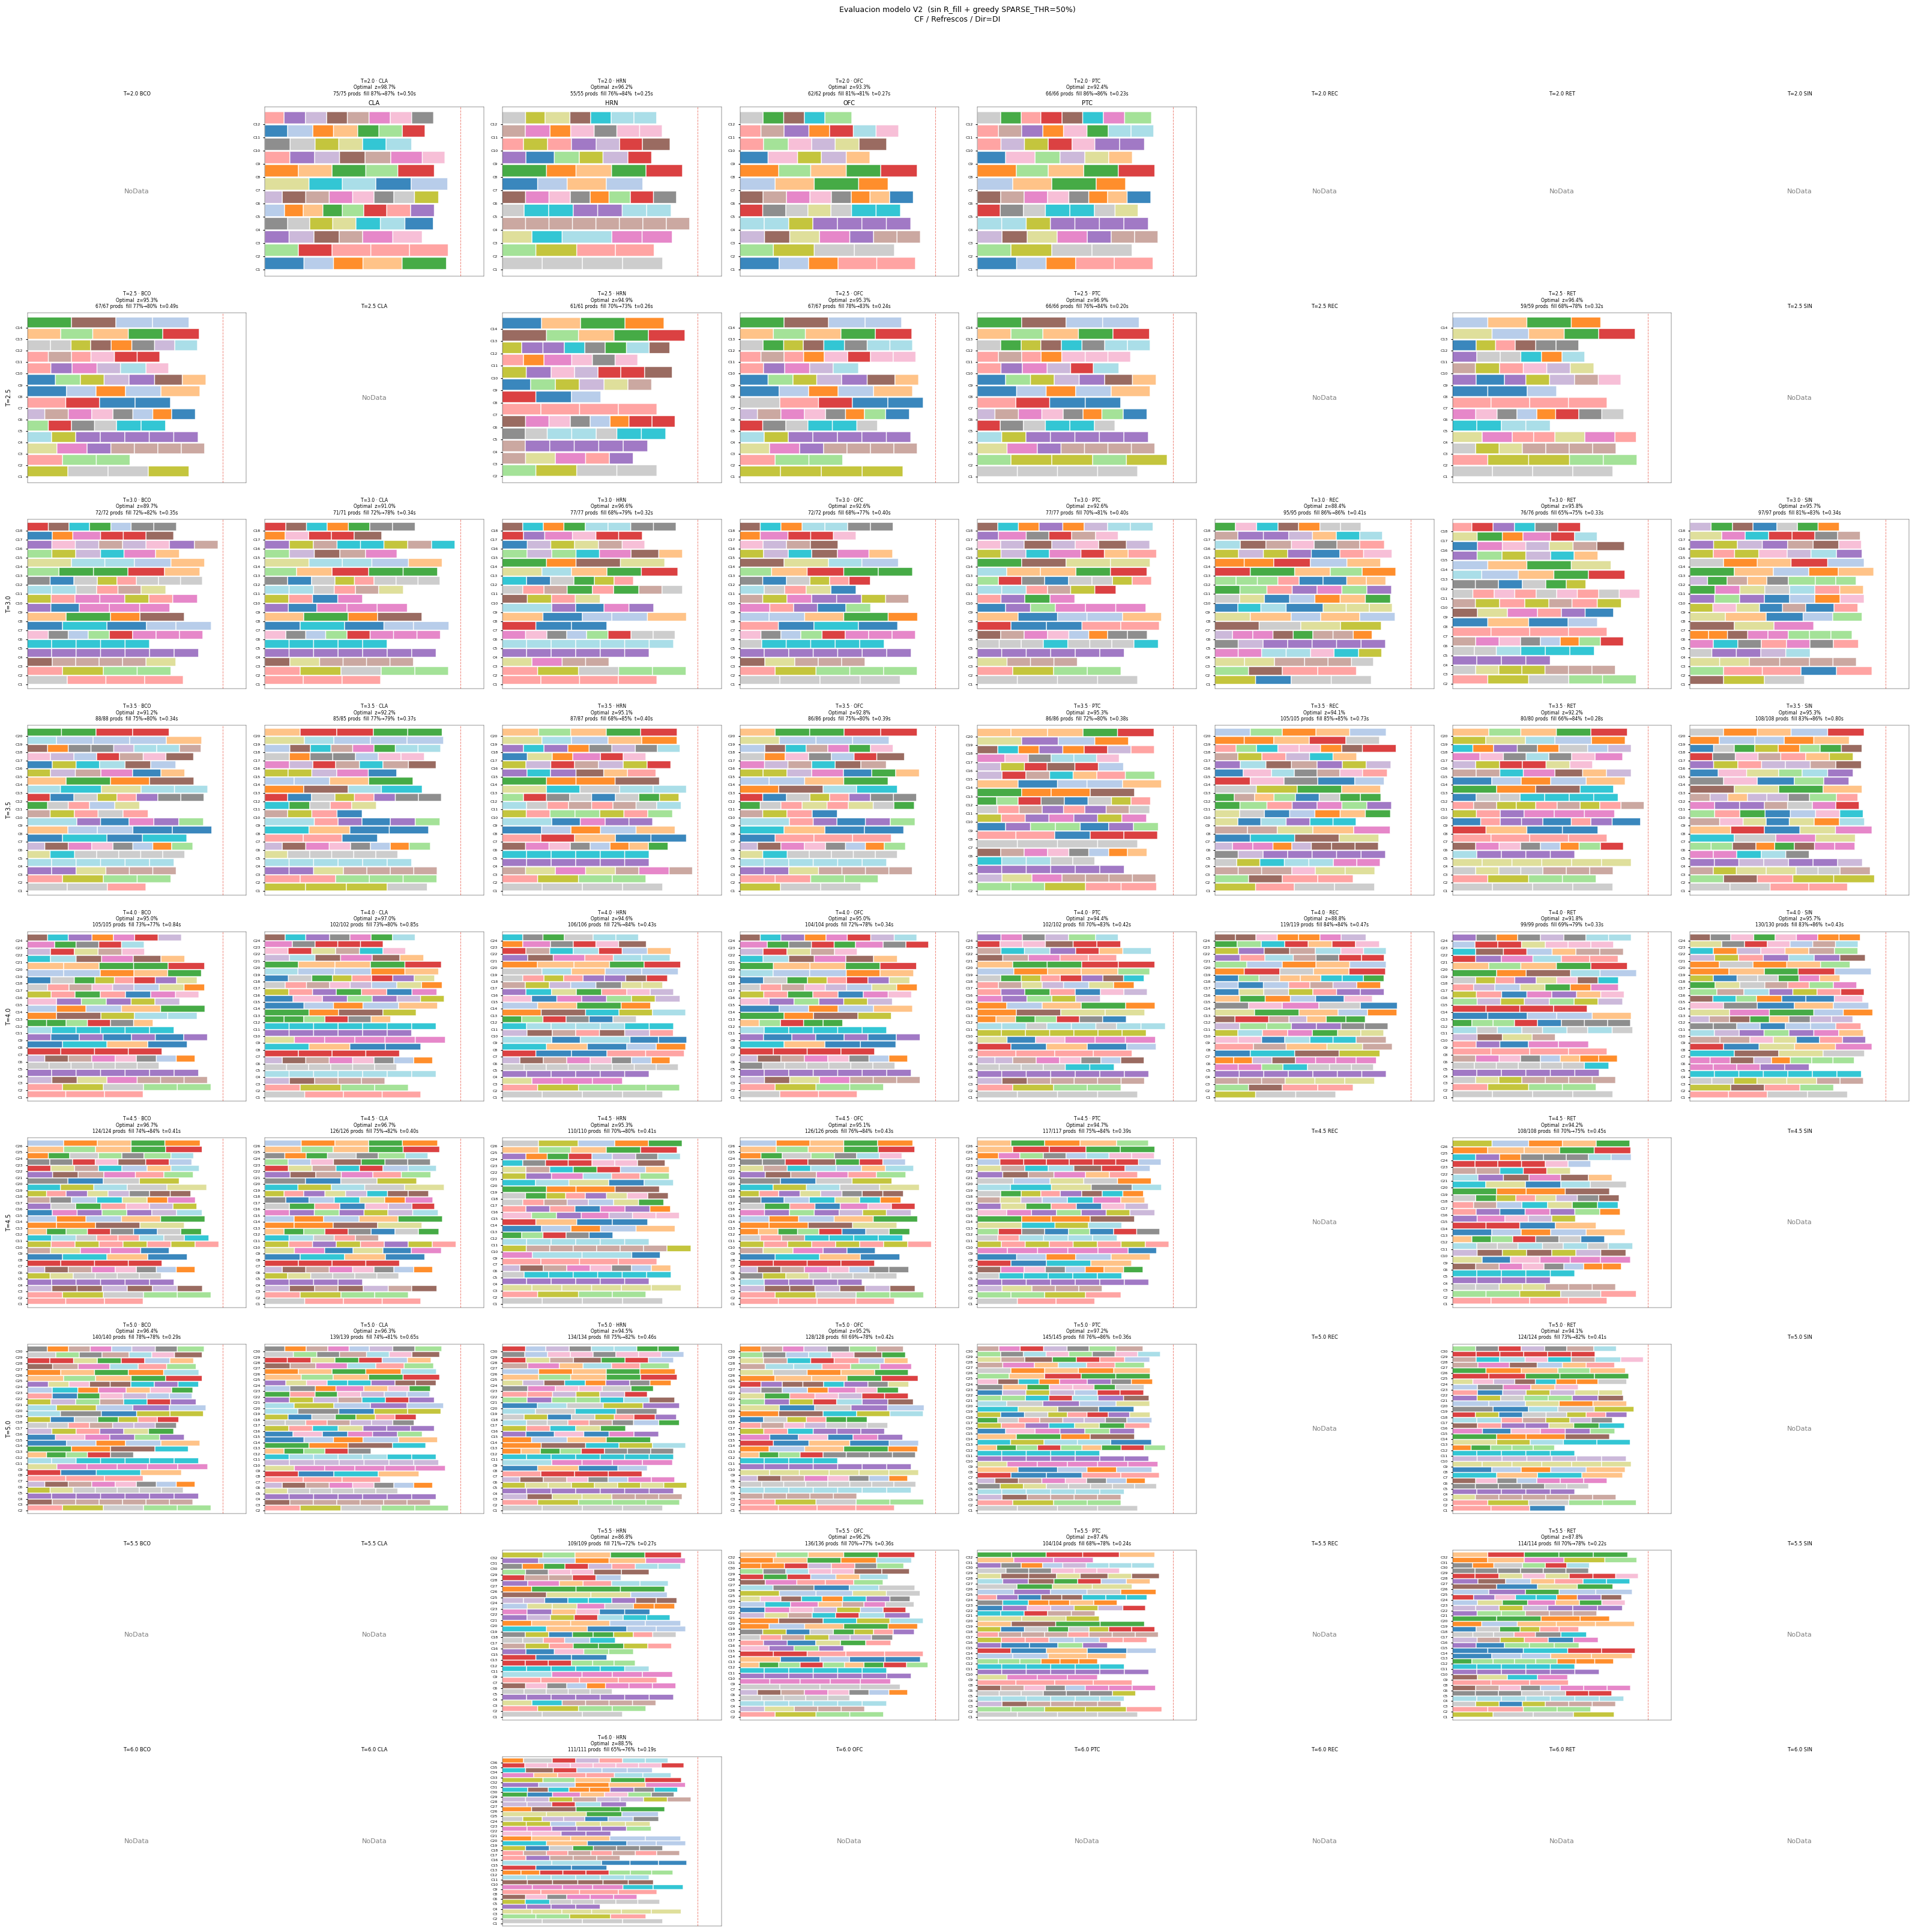

Guardado: out/v2_evaluacion_grid_CF_Refrescos_DI.png

  EVALUACION GLOBAL DEL MODELO V2
  Combinaciones resueltas  : 50 / 50
  Tiempo promedio solver   : 0.40s
  Tiempo maximo            : 0.85s
  Objetivo promedio (z norm): 93.9%
  Fill promedio LP (antes) : 74.2%
  Fill promedio + greedy   : 80.9%
  Mejora media por greedy  : +6.7%
  Extras greedy totales    : 579
  Fill por charola: min=0%  med=86%  max=98%

  Por TAMANO:
    T= 2.0   4 segs  fill 83%→84%  z_norm=95.1%  t_avg=0.31s
    T= 2.5   5 segs  fill 74%→80%  z_norm=95.8%  t_avg=0.30s
    T= 3.0   8 segs  fill 73%→80%  z_norm=92.8%  t_avg=0.36s
    T= 3.5   8 segs  fill 75%→82%  z_norm=93.5%  t_avg=0.46s
    T= 4.0   8 segs  fill 75%→81%  z_norm=94.0%  t_avg=0.51s
    T= 4.5   6 segs  fill 73%→82%  z_norm=95.5%  t_avg=0.42s
    T= 5.0   6 segs  fill 74%→81%  z_norm=95.6%  t_avg=0.43s
    T= 5.5   4 segs  fill 70%→76%  z_norm=89.5%  t_avg=0.28s
    T= 6.0   1 segs  fill 65%→76%  z_norm=88.5%  t_avg=0.19s


In [133]:
# ── Celda N3: Grilla de planogramas + evaluación global del modelo ──────────
# Prerequisito: Celda N2 ejecutada (resultados_v2 disponible).

from collections import defaultdict as _dd3

_tamanos_u   = sorted(set(k[0] for k in resultados_v2))
_segmentos_u = sorted(set(k[1] for k in resultados_v2))
_nr = len(_tamanos_u)
_nc = len(_segmentos_u)

_fig, _axes = plt.subplots(
    _nr, _nc,
    figsize=(max(4 * _nc, 12), max(3.5 * _nr, 8)),
    squeeze=False
)

_cmap_g   = plt.cm.get_cmap('tab20')
_upc_color = {}   # UPC global → color consistente entre subplots

for _ri, _tam in enumerate(_tamanos_u):
    for _ci, _seg in enumerate(_segmentos_u):
        _ax = _axes[_ri][_ci]
        _r  = resultados_v2.get((_tam, _seg))

        if _r is None:
            _ax.text(0.5, 0.5, 'NoData', ha='center', va='center',
                     transform=_ax.transAxes, fontsize=8, color='gray')
            _ax.set_title(f'T={_tam} {_seg}', fontsize=6)
            _ax.set_axis_off()
            continue

        # Título con métricas clave
        _ax.set_title(
            f'T={_tam} · {_seg}\n'
            f'{_r["status"]}  z={_r.get("obj_norm", _r["obj"]/max(_r.get("obj_max",_r["obj"] or 1),1e-9)):.1%}\n'
            f'{_r["n_prod"]}/{_r["n_total"]} prods  '
            f'fill {_r["fill_avg_before"]:.0%}→{_r["fill_avg_after"]:.0%}  '
            f't={_r["t_solver"]:.2f}s',
            fontsize=5.5
        )

        if (_r['status'] not in ('Optimal','Feasible') or _r['df_aug'].empty):
            _ax.text(0.5, 0.5, _r['status'], ha='center', va='center',
                     transform=_ax.transAxes, fontsize=9, color='#c0392b')
            _ax.set_axis_off()
            continue

        _df   = _r['df_aug']
        _sw   = _r['shelf_widths']
        _chars = sorted(_df['CHAROLA'].unique())
        _cy    = {c: i for i, c in enumerate(_chars)}
        _A_max = max(_sw.get(c, _df.groupby('CHAROLA')['ANCHO'].sum().get(c, 55.0))
                     for c in _chars) if _chars else 55.0

        # Agrupar filas por charola
        _c_rows = _dd3(list)
        for _, _row in _df.iterrows():
            _c_rows[int(_row['CHAROLA'])].append(_row)

        for _c, _rows_c in _c_rows.items():
            _x = 0.0; _y0 = _cy[_c]
            for _row in sorted(_rows_c, key=lambda r_: int(r_['UBICACION_BANDEJA'])):
                _upc = int(_row['ITEM']); _w = float(_row['ANCHO'])
                if _upc not in _upc_color:
                    _upc_color[_upc] = _cmap_g(len(_upc_color) % 20)
                _ax.add_patch(mpatches.FancyBboxPatch(
                    (_x, _y0 + 0.05), max(_w - 0.2, 0.05), 0.85,
                    boxstyle='round,pad=0.02',
                    facecolor=_upc_color[_upc],
                    edgecolor='white', linewidth=0.4, alpha=0.88
                ))
                _x += _w

        # Límite rojo de capacidad y etiquetas
        _ax.axvline(_A_max, color='#e74c3c', linestyle='--', linewidth=0.7, alpha=0.7)
        _ax.set_xlim(0, _A_max * 1.12)
        _ax.set_ylim(-0.5, len(_chars) + 0.3)
        _ax.set_yticks(list(_cy.values()))
        _ax.set_yticklabels([f'C{c}' for c in _chars], fontsize=4.5)
        _ax.tick_params(left=True, bottom=False, labelbottom=False, length=2)
        for _sp in _ax.spines.values():
            _sp.set_linewidth(0.3)

    # Etiqueta de TAMANO al lado izquierdo
    _axes[_ri][0].set_ylabel(f'T={_tam}', fontsize=7, labelpad=4)

# Etiquetas de SEGMENTO en la fila superior
for _ci, _seg in enumerate(_segmentos_u):
    _axes[0][_ci].set_xlabel(_seg, fontsize=7, labelpad=2)
    _axes[0][_ci].xaxis.set_label_position('top')

_fig.suptitle(
    f'Evaluacion modelo V2  (sin R_fill + greedy SPARSE_THR={SPARSE_THR_BATCH:.0%})\n'
    f'{MUEBLE} / {PLANOGRUPO_SEL} / Dir={DIRECCION}',
    fontsize=9, y=1.02
)
plt.tight_layout(h_pad=1.8, w_pad=0.8)
_grid_path = f'out/v2_evaluacion_grid_{MUEBLE}_{PLANOGRUPO_SEL}_{DIRECCION}.png'
plt.savefig(_grid_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'Guardado: {_grid_path}')

# ── Evaluación global ──────────────────────────────────────────────────────────
_rs_ok = [r for r in resultados_v2.values() if r['status'] in ('Optimal','Feasible')]

print('\n' + '=' * 62)
print('  EVALUACION GLOBAL DEL MODELO V2')
print('=' * 62)
if _rs_ok:
    _t_vals    = [r['t_solver']        for r in _rs_ok]
    _fb_vals   = [r['fill_avg_before'] for r in _rs_ok]
    _fa_vals   = [r['fill_avg_after']  for r in _rs_ok]
    # obj_norm disponible desde solve_greedy_v2; fallback a obj/obj_max si viene
    # de resultados_v2 generado antes del patch (evita KeyError)
    _obj_vals  = [r.get('obj_norm', r['obj'] / max(r.get('obj_max', r['obj'] or 1), 1e-9))
                  for r in _rs_ok]
    _fills_all = [f for r in _rs_ok for f in r['fill_after'].values()]

    print(f'  Combinaciones resueltas  : {len(_rs_ok)} / {len(resultados_v2)}')
    print(f'  Tiempo promedio solver   : {sum(_t_vals)/len(_t_vals):.2f}s')
    print(f'  Tiempo maximo            : {max(_t_vals):.2f}s')
    print(f'  Objetivo promedio (z norm): {sum(_obj_vals)/len(_obj_vals):.1%}')
    print(f'  Fill promedio LP (antes) : {sum(_fb_vals)/len(_fb_vals):.1%}')
    print(f'  Fill promedio + greedy   : {sum(_fa_vals)/len(_fa_vals):.1%}')
    print(f'  Mejora media por greedy  : '
          f'{(sum(_fa_vals)/len(_fa_vals) - sum(_fb_vals)/len(_fb_vals)):+.1%}')
    print(f'  Extras greedy totales    : {sum(r["n_greedy_added"] for r in _rs_ok)}')
    print(f'  Fill por charola: '
          f'min={min(_fills_all):.0%}  '
          f'med={float(np.median(_fills_all)):.0%}  '
          f'max={max(_fills_all):.0%}')

    # Tabla resumen por TAMANO
    print()
    print(f'  Por TAMANO:')
    for _t in _tamanos_u:
        _rt = [r for r in _rs_ok if r['tamano'] == _t]
        if not _rt: continue
        print(f'    T={_t:4.1f}  {len(_rt):2d} segs  '
              f'fill {sum(r["fill_avg_before"] for r in _rt)/len(_rt):.0%}'
              f'→{sum(r["fill_avg_after"] for r in _rt)/len(_rt):.0%}  '
              f'z_norm={sum(r.get("obj_norm", r["obj"]/max(r.get("obj_max", r["obj"] or 1),1e-9)) for r in _rt)/len(_rt):.1%}  '
              f't_avg={sum(r["t_solver"] for r in _rt)/len(_rt):.2f}s')
else:
    print('  No hay combinaciones resueltas exitosamente.')
print('=' * 62)
